In [5]:
import os
import grass.script as gs
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score

# Define your land cover classes and colors
landcover_classes = {
    5: 'Shrubland', 
    7: 'Grassland', 
    8: 'Cropland', 
    9: 'Wetland',
    11: 'Lichens/Mosses', 
    12: 'Bareland', 
    13: 'Built-up', 
    15: 'Water',
    16: 'Ice/Snow', 
    20: 'Forest', 
    255: 'No Data'
}

landcover_colors = {
    'Shrubland': '#8C564B',
    'Grassland': '#FF7F0E',
    'Cropland': '#D62728',
    'Wetland': '#1F77B4',
    'Lichens/Mosses': '#9467BD',
    'Bareland': '#7F7F7F',
    'Built-up': '#BCBD22',
    'Water': '#17BECF',
    'Ice/Snow': '#AEC7E8',
    'Forest': '#2CA02C',
    'No Data': '#CCCCCC'
}

def parse_stats_line(line):
    """Parse the complex stats line format from r.stats"""
    try:
        # Handle lines like "5 5-5.058824 18950"
        parts = line.split()
        if len(parts) == 3:
            val1 = float(parts[0])
            val2_range = parts[1].split('-')
            val2 = float(val2_range[0])
            count = int(parts[2])
            return val1, val2, count
        return None
    except:
        return None

def resample_and_compare(high_res_raster, low_res_raster, output_dir, year):
    """Compare high resolution (30m) and low resolution (300m) land cover data."""
    os.makedirs(output_dir, exist_ok=True)
    
    # Set computational region
    gs.run_command('g.region', raster=low_res_raster)
    
    # Resample high resolution raster
    resampled_name = f"resampled_{year}"
    gs.run_command('r.resamp.stats', 
                  input=high_res_raster, 
                  output=resampled_name,
                  method='mode',
                  overwrite=True)
    
    # Apply classification colors
    color_rules = "\n".join(f"{k} {landcover_colors[v]}" for k, v in landcover_classes.items())
    gs.write_command('r.colors', map=resampled_name, rules='-', stdin=color_rules)
    
    # Create agreement map
    agreement_map = f"agreement_{year}"
    gs.mapcalc(f"{agreement_map} = if({low_res_raster} == {resampled_name}, 1, 0)",
              overwrite=True)
    
    # Apply color scheme to agreement map
    color_file = os.path.join(output_dir, f"agreement_colors_{year}.txt")
    with open(color_file, 'w') as f:
        f.write("0 red\n1 green")
    gs.run_command('r.colors', map=agreement_map, rules=color_file)
    os.remove(color_file)
    
    # Get statistics with proper format
    stats_raw = gs.read_command('r.stats', flags='cn', input=f"{low_res_raster},{resampled_name}")
    if not stats_raw:
        print(f"⚠️ No statistics generated for {year}")
        return None
    
    # Parse statistics
    low_res_values = []
    high_res_values = []
    
    for line in stats_raw.strip().split('\n'):
        parsed = parse_stats_line(line)
        if parsed:
            val1, val2, count = parsed
            # Round to nearest integer class value
            val1_int = int(round(val1))
            val2_int = int(round(val2))
            
            if val1_int in landcover_classes and val2_int in landcover_classes:
                low_res_values.extend([val1_int] * count)
                high_res_values.extend([val2_int] * count)
    
    if not low_res_values:
        print(f"⚠️ No valid pixel comparisons for {year}")
        return None
    
    # Calculate metrics
    cm = confusion_matrix(low_res_values, high_res_values)
    overall_accuracy = accuracy_score(low_res_values, high_res_values)
    kappa = cohen_kappa_score(low_res_values, high_res_values)
    
    # Producer's and User's accuracy
    with np.errstate(divide='ignore', invalid='ignore'):
        producer_acc = np.nan_to_num(cm.diagonal() / cm.sum(axis=1), nan=0)
        user_acc = np.nan_to_num(cm.diagonal() / cm.sum(axis=0), nan=0)
    
    # Export maps with proper data types to avoid GDAL warnings
    # Agreement map (Byte type)
    agreement_path = os.path.join(output_dir, f"agreement_{year}.tif")
    gs.run_command('r.out.gdal',
                  input=agreement_map,
                  output=agreement_path,
                  format='GTiff',
                  type='Byte',
                  createopt='COMPRESS=DEFLATE',
                  overwrite=True)
    
    # Resampled map (use Float64 to avoid precision loss)
    resampled_path = os.path.join(output_dir, f"resampled_{year}.tif")
    gs.run_command('r.out.gdal',
                  input=resampled_name,
                  output=resampled_path,
                  format='GTiff',
                  type='Float64',
                  createopt='COMPRESS=DEFLATE',
                  flags='f',  # Force override precision warning
                  overwrite=True)
    
    # Reference map (Byte type)
    reference_path = os.path.join(output_dir, f"reference_{year}.tif")
    gs.run_command('r.out.gdal',
                  input=low_res_raster,
                  output=reference_path,
                  format='GTiff',
                  type='Byte',
                  createopt='COMPRESS=DEFLATE',
                  overwrite=True)
    
    # Save results
    results = {
        'year': year,
        'confusion_matrix': cm,
        'overall_accuracy': overall_accuracy,
        'kappa_coefficient': kappa,
        'producer_accuracy': producer_acc,
        'user_accuracy': user_acc,
        'class_labels': landcover_classes
    }
    
    results_file = os.path.join(output_dir, f"metrics_{year}.txt")
    with open(results_file, 'w') as f:
        f.write(f"Comparison Results for {year}\n")
        f.write(f"Overall Accuracy: {overall_accuracy:.4f}\n")
        f.write(f"Kappa Coefficient: {kappa:.4f}\n\n")
        
        f.write("Class-wise Metrics:\n")
        for i, (class_id, class_name) in enumerate(landcover_classes.items()):
            if i < len(producer_acc):
                f.write(f"{class_name}: Producer's={producer_acc[i]:.2%}, User's={user_acc[i]:.2%}\n")
        
        f.write("\nConfusion Matrix:\n")
        np.savetxt(f, cm, fmt='%d')
    
    print(f"\n✅ Analysis completed for year {year}")
    return results

def main():
    """Main comparison analysis workflow."""
    output_base_dir = "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1"
    
    # All years to process (2000-2022, even years)
    years_to_compare = [
        '2000', '2002', '2004', '2006', '2008', 
        '2010', '2012', '2014', '2016', '2018', 
        '2020', '2022'
    ]
    
    # Verify projection
    proj_info = gs.read_command('g.proj', flags='p')
    if 'EPSG:3035' not in proj_info:
        print("Error: Projection must be EPSG:3035 (ETRS89-LAEA)")
        return
    
    all_results = []
    
    for year in years_to_compare:
        print(f"\nStarting analysis for year {year}...")
        
        # Define raster names
        high_res = f"glc_{year}@PERMANENT"
        low_res = f"cci_{year}@PERMANENT"
        
        # Check raster existence
        if not gs.find_file(low_res, element='cell')['file']:
            print(f"⚠️ Skipping {year} - {low_res} not found")
            continue
        if not gs.find_file(high_res, element='cell')['file']:
            print(f"⚠️ Skipping {year} - {high_res} not found")
            continue
        
        # Create year-specific output directory
        year_output_dir = os.path.join(output_base_dir, year)
        
        # Run the comparison
        results = resample_and_compare(
            high_res_raster=high_res,
            low_res_raster=low_res,
            output_dir=year_output_dir,
            year=year
        )
        
        if results:
            all_results.append(results)
            # Print summary to console
            print(f"\nSummary for {year}:")
            print(f"Overall Accuracy: {results['overall_accuracy']:.2%}")
            print(f"Kappa Coefficient: {results['kappa_coefficient']:.3f}")

    # Save combined results
    if all_results:
        combined_file = os.path.join(output_base_dir, "all_years_metrics.csv")
        combined_df = pd.DataFrame(all_results)
        combined_df.to_csv(combined_file, index=False)
        print(f"\nSaved combined results to: {combined_file}")

    print("\nAll comparisons completed!")

if __name__ == "__main__":
    main()

    


Starting analysis for year 2000...



Color table for raster map <resampled_2000> set to 'rules'
Color table for raster map <agreement_2000> set to
'/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2000/agreement_colors_2000.txt'

Checking GDAL data type and nodata value...

Using GDAL data type <Byte>
Input raster map contains cells with NULL-value (no-data). The value 255
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File
</Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2000/agreement_2000.tif>
created.
Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...
ERROR 6: resampled_2000.tif, band 1: SetColorTable() only 


✅ Analysis completed for year 2000

Summary for 2000:
Overall Accuracy: 78.06%
Kappa Coefficient: 0.639

Starting analysis for year 2002...



Color table for raster map <resampled_2002> set to 'rules'
Color table for raster map <agreement_2002> set to
'/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2002/agreement_colors_2002.txt'

Checking GDAL data type and nodata value...

Using GDAL data type <Byte>
Input raster map contains cells with NULL-value (no-data). The value 255
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File
</Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2002/agreement_2002.tif>
created.
Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...
ERROR 6: resampled_2002.tif, band 1: SetColorTable() only 


✅ Analysis completed for year 2002

Summary for 2002:
Overall Accuracy: 78.41%
Kappa Coefficient: 0.645

Starting analysis for year 2004...


...


Color table for raster map <resampled_2020> set to 'rules'
Color table for raster map <agreement_2020> set to
'/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2020/agreement_colors_2020.txt'

Checking GDAL data type and nodata value...

Using GDAL data type <Byte>
Input raster map contains cells with NULL-value (no-data). The value 255
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File
</Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2020/agreement_2020.tif>
created.
Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...
ERROR 6: resampled_2020.tif, band 1: SetColorTable() only 


✅ Analysis completed for year 2020

Summary for 2020:
Overall Accuracy: 78.75%
Kappa Coefficient: 0.654

Starting analysis for year 2022...



Color table for raster map <resampled_2022> set to 'rules'
Color table for raster map <agreement_2022> set to
'/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2022/agreement_colors_2022.txt'

Checking GDAL data type and nodata value...

Using GDAL data type <Byte>
Input raster map contains cells with NULL-value (no-data). The value 255
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...

r.out.gdal complete. File
</Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2022/agreement_2022.tif>
created.
Checking GDAL data type and nodata value...

Using GDAL data type <Float64>
Input raster map contains cells with NULL-value (no-data). The value nan
will be used to represent no-data values in the input map. You can specify
a nodata value with the nodata option.
Exporting raster data to GTiff format...
ERROR 6: resampled_2022.tif, band 1: SetColorTable() only 


✅ Analysis completed for year 2022

Summary for 2022:
Overall Accuracy: 78.77%
Kappa Coefficient: 0.654

Saved combined results to: /Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/all_years_metrics.csv

All comparisons completed!


r.out.gdal complete. File
</Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2022/reference_2022.tif>
created.


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec
from matplotlib.patches import Rectangle
import rasterio

# -------------------------
# Paths & data
# -------------------------
base_dir = "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1"

landcover_classes = {
    5: 'Shrubland',
    7: 'Grassland',
    8: 'Cropland',
    9: 'Wetland',
    11: 'Lichens/Mosses',
    12: 'Bareland',
    13: 'Built-up',
    15: 'Water',
    16: 'Ice/Snow',
    20: 'Forest'
}

landcover_colors = {
    5:  '#8B4513',
    7:  '#D2B48C',
    8:  '#FFA500',
    9:  '#4682B4',
    11: '#9370DB',
    12: '#A9A9A9',
    13: '#CD5C5C',
    15: '#1E90FF',
    16: '#F0FFFF',
    20: '#228B22'
}

# Example metrics — replace with real data
all_metrics = {
    '2000': {
        'overall_accuracy': 0.781,
        'kappa_coefficient': 0.64,
        'producer_accuracy': np.random.rand(10),
        'user_accuracy': np.random.rand(10),
    },
    '2002': {
        'overall_accuracy': 0.784,
        'kappa_coefficient': 0.65,
        'producer_accuracy': np.random.rand(10),
        'user_accuracy': np.random.rand(10),
    }
}

# -------------------------
# Table creator
# -------------------------
def create_perfect_table(ax, class_data):
    """
    Creates a large, readable table with clear background separation.
    """
    table = ax.table(
        cellText=class_data,
        colLabels=["Land Cover Class", "Producer's Accuracy (%)", "User's Accuracy (%)"],
        loc='center',
        cellLoc='center'
    )

    # Big readable text
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.4, 1.6)

    # Styling cells
    for (i, j), cell in table.get_celld().items():
        cell.set_edgecolor('gray')
        cell.set_linewidth(0.6)

        if i == 0:  # Header
            cell.set_facecolor('#222222')
            cell.get_text().set_color('white')
            cell.get_text().set_weight('bold')
        elif j == 0:  # Class name with color swatch
            class_name = class_data[i-1][0]
            class_id = [k for k, v in landcover_classes.items() if v == class_name][0]
            cell.set_facecolor(landcover_colors[class_id])
            # Pick black/white text based on luminance
            rgb = tuple(int(landcover_colors[class_id].lstrip('#')[k:k+2], 16) for k in (0, 2, 4))
            luminance = 0.2126*rgb[0]/255 + 0.7152*rgb[1]/255 + 0.0722*rgb[2]/255
            cell.get_text().set_color('black' if luminance > 0.6 else 'white')
            cell.get_text().set_weight('bold')
        else:  # Data cells
            cell.set_facecolor('white')

    return table

# -------------------------
# Plot function
# -------------------------
def plot_year_comparison(year, metrics):
    plot_dir = os.path.join(base_dir, "final_perfect_plots")
    os.makedirs(plot_dir, exist_ok=True)

    with rasterio.open(os.path.join(base_dir, year, f"reference_{year}.tif")) as ref_src, \
         rasterio.open(os.path.join(base_dir, year, f"resampled_{year}.tif")) as res_src, \
         rasterio.open(os.path.join(base_dir, year, f"agreement_{year}.tif")) as agr_src:

        ref_data = np.ma.masked_equal(ref_src.read(1), ref_src.nodata)
        res_data = np.ma.masked_equal(res_src.read(1), res_src.nodata)
        agr_data = np.ma.masked_equal(agr_src.read(1), agr_src.nodata)

        fig = plt.figure(figsize=(22, 14))
        gs = gridspec.GridSpec(2, 3, height_ratios=[3, 1], width_ratios=[1, 1, 1.2])

        ax1 = fig.add_subplot(gs[0, 0]); ax1.set_axis_off()
        ax2 = fig.add_subplot(gs[0, 1]); ax2.set_axis_off()
        ax3 = fig.add_subplot(gs[0, 2]); ax3.set_axis_off()

        # Landcover maps
        keys = sorted(landcover_classes.keys())
        cmap_lc = mcolors.ListedColormap([landcover_colors[k] for k in keys])
        bounds = np.array(keys + [keys[-1] + 1]) - 0.5
        norm_lc = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cmap_lc.N)

        ax1.imshow(ref_data, cmap=cmap_lc, norm=norm_lc)
        ax1.set_title('Reference (CCI)', fontsize=14, pad=10)

        ax2.imshow(res_data, cmap=cmap_lc, norm=norm_lc)
        ax2.set_title('Resampled (GLC)', fontsize=14, pad=10)

        cmap_agr = mcolors.ListedColormap(['#D62728', '#2CA02C'])
        norm_agr = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], 2)
        im_agr = ax3.imshow(agr_data, cmap=cmap_agr, norm=norm_agr)
        ax3.set_title(f'Agreement (κ={metrics["kappa_coefficient"]:.2f})', fontsize=14, pad=10)

        cbar = plt.colorbar(im_agr, ax=ax3, fraction=0.046, pad=0.04)
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['Disagree', 'Agree'])

        # Table section
        ax4 = fig.add_subplot(gs[1, :])
        ax4.axis('off')

        # Background patch behind table for clarity
        ax4.add_patch(Rectangle(
            (-0.05, -0.05), 1.1, 1.1,
            transform=ax4.transAxes, color='white', alpha=0.85, zorder=-1
        ))

        # Table title
        ax4.set_title('Per-Class Accuracies (%)', fontsize=16, weight='bold', pad=12)

        # Build table data
        class_data = []
        for i, class_id in enumerate(keys):
            class_name = landcover_classes[class_id]
            prod_acc = metrics['producer_accuracy'][i] * 100
            user_acc = metrics['user_accuracy'][i] * 100
            class_data.append([class_name, f"{prod_acc:.1f}", f"{user_acc:.1f}"])

        create_perfect_table(ax4, class_data)

        fig.text(
            0.5, 0.93,
            f"Land Cover Comparison {year} | Overall Accuracy: {metrics['overall_accuracy']*100:.1f}%",
            ha='center', fontsize=18, weight='bold'
        )

        plt.subplots_adjust(top=0.90, hspace=0.5, wspace=0.25)
        plt.savefig(os.path.join(plot_dir, f"perfect_{year}.png"), dpi=600, bbox_inches='tight')
        plt.close()

# -------------------------
# Run all years
# -------------------------
for year in sorted(os.listdir(base_dir)):
    if os.path.isdir(os.path.join(base_dir, year)) and year in all_metrics:
        print(f"Processing year {year}...")
        plot_year_comparison(year, all_metrics[year])


Processing year 2000...
Processing year 2002...


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec
from matplotlib.patches import Rectangle
import rasterio
import json

# -------------------------
# Paths
# -------------------------
base_dir = "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1"
plot_dir = os.path.join(base_dir, "final_perfect_plots")
os.makedirs(plot_dir, exist_ok=True)

# -------------------------
# Class definitions
# -------------------------
landcover_classes = {
    5: 'Shrubland',
    7: 'Grassland',
    8: 'Cropland',
    9: 'Wetland',
    11: 'Lichens/Mosses',
    12: 'Bareland',
    13: 'Built-up',
    15: 'Water',
    16: 'Ice/Snow',
    20: 'Forest'
}

landcover_colors = {
    5:  '#8B4513',
    7:  '#D2B48C',
    8:  '#FFA500',
    9:  '#4682B4',
    11: '#9370DB',
    12: '#A9A9A9',
    13: '#CD5C5C',
    15: '#1E90FF',
    16: '#F0FFFF',
    20: '#228B22'
}

# -------------------------
# Load metrics from JSON (optional)
# -------------------------
# Example: metrics.json inside base_dir containing dict like:
# {"2000": {...}, "2002": {...}}
metrics_path = os.path.join(base_dir, "metrics.json")
if os.path.exists(metrics_path):
    with open(metrics_path, "r") as f:
        all_metrics = json.load(f)
else:
    # Placeholder example (replace with real data)
    all_metrics = {
        '2000': {
            'overall_accuracy': 0.781,
            'kappa_coefficient': 0.64,
            'producer_accuracy': np.random.rand(10).tolist(),
            'user_accuracy': np.random.rand(10).tolist(),
        },
        '2002': {
            'overall_accuracy': 0.784,
            'kappa_coefficient': 0.65,
            'producer_accuracy': np.random.rand(10).tolist(),
            'user_accuracy': np.random.rand(10).tolist(),
        }
    }

# -------------------------
# Table creator
# -------------------------
def create_perfect_table(ax, class_data):
    table = ax.table(
        cellText=class_data,
        colLabels=["Land Cover Class", "Producer's Accuracy (%)", "User's Accuracy (%)"],
        loc='center',
        cellLoc='center'
    )

    # Bigger font
    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.4, 1.6)

    for (i, j), cell in table.get_celld().items():
        cell.set_edgecolor('gray')
        cell.set_linewidth(0.6)

        if i == 0:  # Header row
            cell.set_facecolor('#222222')
            cell.get_text().set_color('white')
            cell.get_text().set_weight('bold')
        elif j == 0:  # Class name with swatch
            class_name = class_data[i-1][0]
            class_id = [k for k, v in landcover_classes.items() if v == class_name][0]
            cell.set_facecolor(landcover_colors[class_id])
            rgb = tuple(int(landcover_colors[class_id].lstrip('#')[k:k+2], 16) for k in (0, 2, 4))
            luminance = 0.2126*rgb[0]/255 + 0.7152*rgb[1]/255 + 0.0722*rgb[2]/255
            cell.get_text().set_color('black' if luminance > 0.6 else 'white')
            cell.get_text().set_weight('bold')
        else:  # Numeric cells
            cell.set_facecolor('white')

    return table

# -------------------------
# Plot function
# -------------------------
def plot_year_comparison(year, metrics):
    with rasterio.open(os.path.join(base_dir, year, f"reference_{year}.tif")) as ref_src, \
         rasterio.open(os.path.join(base_dir, year, f"resampled_{year}.tif")) as res_src, \
         rasterio.open(os.path.join(base_dir, year, f"agreement_{year}.tif")) as agr_src:

        ref_data = np.ma.masked_equal(ref_src.read(1), ref_src.nodata)
        res_data = np.ma.masked_equal(res_src.read(1), res_src.nodata)
        agr_data = np.ma.masked_equal(agr_src.read(1), agr_src.nodata)

        fig = plt.figure(figsize=(22, 14))
        gs = gridspec.GridSpec(2, 3, height_ratios=[3, 1], width_ratios=[1, 1, 1.2])

        # Map panels
        ax1 = fig.add_subplot(gs[0, 0]); ax1.set_axis_off()
        ax2 = fig.add_subplot(gs[0, 1]); ax2.set_axis_off()
        ax3 = fig.add_subplot(gs[0, 2]); ax3.set_axis_off()

        keys = sorted(landcover_classes.keys())
        cmap_lc = mcolors.ListedColormap([landcover_colors[k] for k in keys])
        bounds = np.array(keys + [keys[-1] + 1]) - 0.5
        norm_lc = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cmap_lc.N)

        ax1.imshow(ref_data, cmap=cmap_lc, norm=norm_lc)
        ax1.set_title('Reference (CCI)', fontsize=16, pad=12, weight='bold')

        ax2.imshow(res_data, cmap=cmap_lc, norm=norm_lc)
        ax2.set_title('Resampled (GLC)', fontsize=16, pad=12, weight='bold')

        cmap_agr = mcolors.ListedColormap(['#D62728', '#2CA02C'])
        norm_agr = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], 2)
        im_agr = ax3.imshow(agr_data, cmap=cmap_agr, norm=norm_agr)
        ax3.set_title(f'Agreement (κ={metrics["kappa_coefficient"]:.2f})', fontsize=16, pad=12, weight='bold')

        cbar = plt.colorbar(im_agr, ax=ax3, fraction=0.046, pad=0.04)
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['Disagree', 'Agree'])

        # Table panel
        ax4 = fig.add_subplot(gs[1, :])
        ax4.axis('off')

        # Title for the table
        ax4.set_title('Per-Class Producer’s & User’s Accuracy (%)',
                      fontsize=18, weight='bold', pad=18, color='#222222')

        # Background patch behind table
        ax4.add_patch(Rectangle((-0.05, -0.05), 1.1, 1.1,
                                transform=ax4.transAxes,
                                color='white', alpha=0.9, zorder=-1))

        # Prepare table data
        class_data = []
        for i, class_id in enumerate(keys):
            class_name = landcover_classes[class_id]
            prod_acc = metrics['producer_accuracy'][i] * 100
            user_acc = metrics['user_accuracy'][i] * 100
            class_data.append([class_name, f"{prod_acc:.1f}", f"{user_acc:.1f}"])

        create_perfect_table(ax4, class_data)

        # Main title
        fig.text(0.5, 0.93,
                 f"Land Cover Comparison {year} | Overall Accuracy: {metrics['overall_accuracy']*100:.1f}%",
                 ha='center', fontsize=20, weight='bold')

        plt.subplots_adjust(top=0.90, hspace=0.5, wspace=0.25)
        plt.savefig(os.path.join(plot_dir, f"perfect_{year}.png"), dpi=600, bbox_inches='tight')
        plt.close()

# -------------------------
# Process all years
# -------------------------
for year in sorted(os.listdir(base_dir)):
    if os.path.isdir(os.path.join(base_dir, year)) and year in all_metrics:
        print(f"Processing {year}...")
        plot_year_comparison(year, all_metrics[year])




Processing 2000...
Processing 2002...


In [1]:
import pandas as pd

# Paths to metrics files
metrics_files = {
    "2000": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2000/metrics_2000.txt",
    "2002": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2002/metrics_2002.txt",
    "2004": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2004/metrics_2004.txt",
    "2006": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2006/metrics_2006.txt",
    "2008": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2008/metrics_2008.txt",
    "2010": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2010/metrics_2010.txt",
    "2012": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2012/metrics_2012.txt",
    "2014": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2014/metrics_2014.txt",
    "2016": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2016/metrics_2016.txt",
    "2018": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2018/metrics_2018.txt",
    "2020": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2020/metrics_2020.txt",
    "2022": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2022/metrics_2022.txt"
   
  
}

def parse_metrics(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Extract overall accuracy and kappa
    overall_accuracy = float(lines[1].split(":")[1].strip())
    kappa = float(lines[2].split(":")[1].strip())
    
    # Extract class-wise metrics
    class_metrics = []
    in_class_section = False
    for line in lines:
        if "Class-wise Metrics" in line:
            in_class_section = True
            continue
        if in_class_section and line.strip() == "":
            break
        if in_class_section:
            try:
                name, rest = line.split(":")
                prod_str, user_str = rest.split(",")
                producer_acc = float(prod_str.split("=")[1].replace("%","")) / 100
                user_acc = float(user_str.split("=")[1].replace("%","")) / 100
                class_metrics.append({
                    "Class": name.strip(),
                    "Producer Accuracy": producer_acc,
                    "User Accuracy": user_acc
                })
            except ValueError:
                pass  # Skip malformed lines
    
    return overall_accuracy, kappa, pd.DataFrame(class_metrics)

# Load both years into a combined DataFrame
summary_data = []
class_dfs = {}
for year, path in metrics_files.items():
    overall, kappa, class_df = parse_metrics(path)
    summary_data.append({
        "Year": year,
        "Overall Accuracy": overall,
        "Kappa Coefficient": kappa
    })
    class_df["Year"] = year
    class_dfs[year] = class_df

summary_df = pd.DataFrame(summary_data)
class_metrics_df = pd.concat(class_dfs.values(), ignore_index=True)

# Display in Jupyter
import IPython.display as display
display.display(summary_df)
display.display(class_metrics_df)



,Year,Overall Accuracy,Kappa Coefficient
0,2000,0.7806,0.6394
1,2002,0.7841,0.6454
2,2004,0.7868,0.6507
3,2006,0.7886,0.6544
4,2008,0.7913,0.6593
5,2010,0.7912,0.6594
6,2012,0.7913,0.6595
7,2014,0.7903,0.6585
8,2016,0.7903,0.6588
9,2018,0.7895,0.6573


,Class,Producer Accuracy,User Accuracy,Year
0,Shrubland,0.2100,0.2527,2000
1,Grassland,0.3048,0.5307,2000
2,Cropland,0.8276,0.8892,2000
3,Wetland,0.4497,0.2340,2000
4,Lichens/Mosses,0.0000,0.0000,2000
...,...,...,...,...
115,Bareland,0.0474,0.7051,2022
116,Built-up,0.7584,0.8004,2022
117,Water,0.7363,0.8874,2022
118,Ice/Snow,0.9222,0.3037,2022


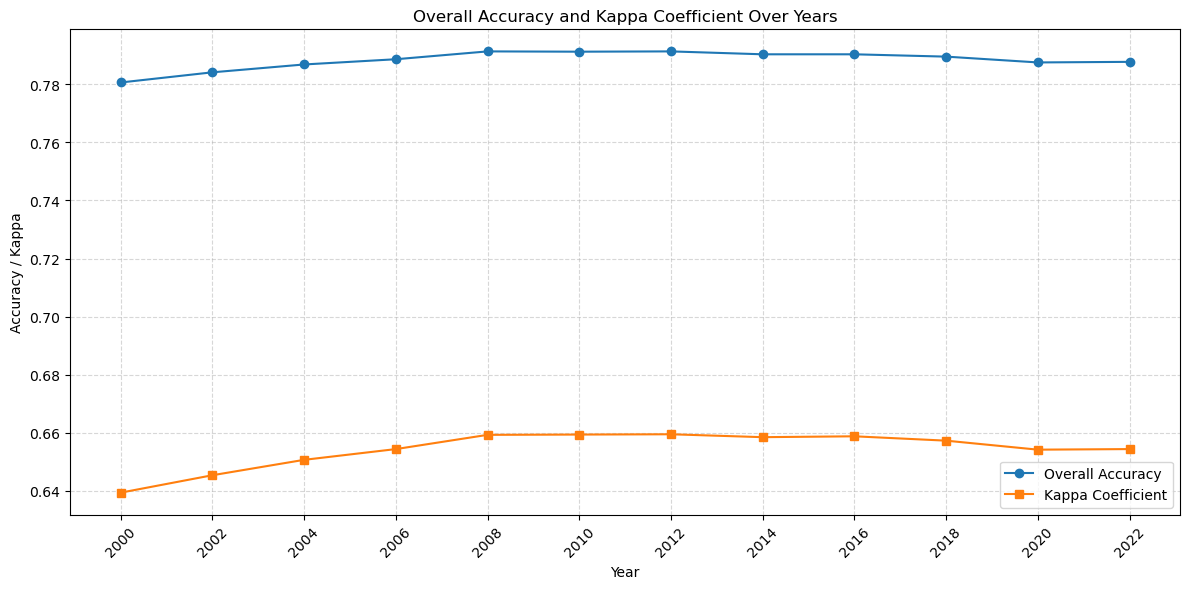

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(summary_df['Year'], summary_df['Overall Accuracy'], marker='o', label='Overall Accuracy')
plt.plot(summary_df['Year'], summary_df['Kappa Coefficient'], marker='s', label='Kappa Coefficient')
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Accuracy / Kappa')
plt.title('Overall Accuracy and Kappa Coefficient Over Years')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


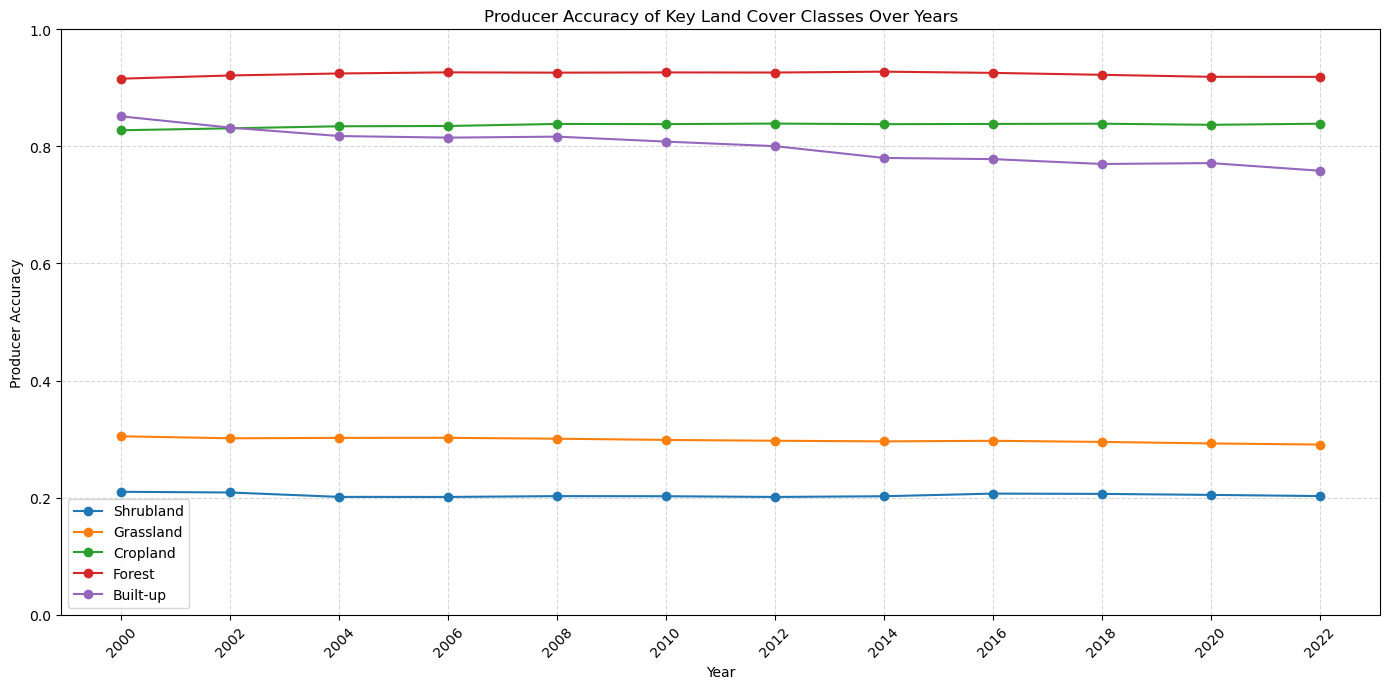

In [3]:
import seaborn as sns

key_classes = ['Shrubland', 'Grassland', 'Cropland', 'Forest', 'Built-up']

plt.figure(figsize=(14,7))
for cls in key_classes:
    cls_data = class_metrics_df[class_metrics_df['Class'] == cls]
    plt.plot(cls_data['Year'], cls_data['Producer Accuracy'], marker='o', label=cls)

plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Producer Accuracy')
plt.title('Producer Accuracy of Key Land Cover Classes Over Years')
plt.ylim(0,1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Figure saved as: /Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/accuracy_trends_over_years.png


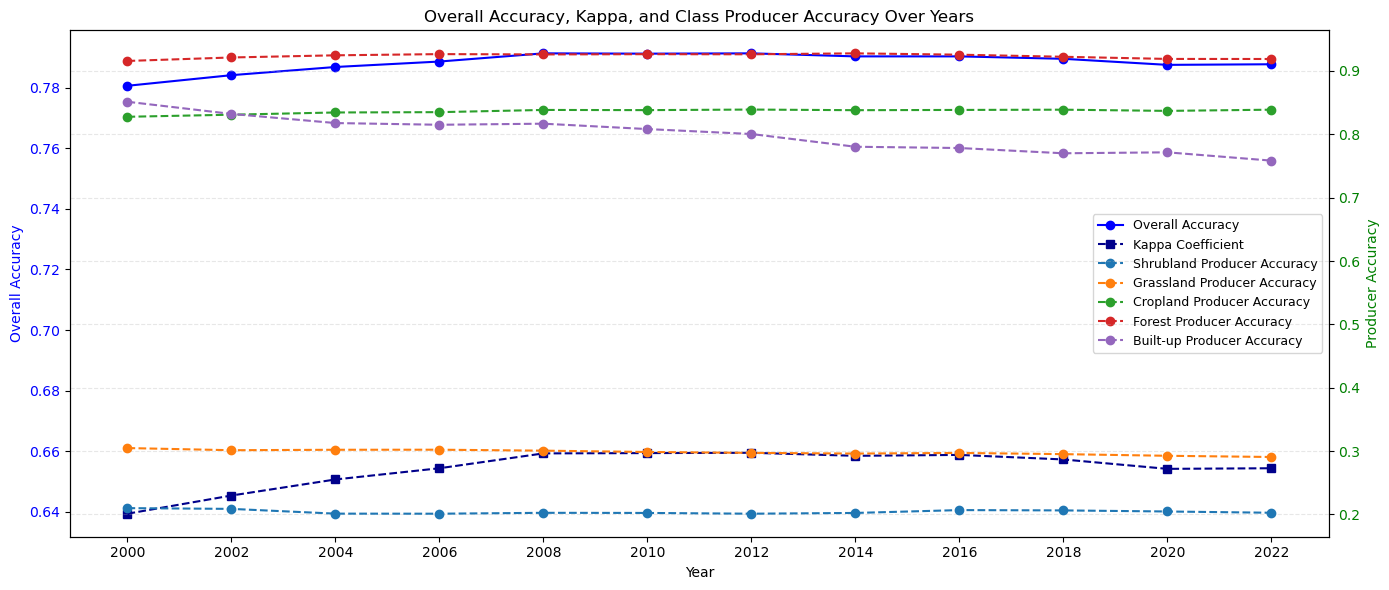

In [5]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,6))

# Overall accuracy on left y-axis
ax1.plot(summary_df['Year'], summary_df['Overall Accuracy'], 'o-', color='blue', label='Overall Accuracy')
ax1.set_xlabel('Year')
ax1.set_ylabel('Overall Accuracy', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Kappa on same axis but dashed
ax1.plot(summary_df['Year'], summary_df['Kappa Coefficient'], 's--', color='darkblue', label='Kappa Coefficient')

# Class-level producer accuracy on right y-axis
ax2 = ax1.twinx()
for cls in key_classes:
    cls_data = class_metrics_df[class_metrics_df['Class'] == cls]
    ax2.plot(cls_data['Year'], cls_data['Producer Accuracy'], marker='o', linestyle='--', label=f'{cls} Producer Accuracy')
ax2.set_ylabel('Producer Accuracy', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Legends
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='center right', fontsize=9)

plt.title('Overall Accuracy, Kappa, and Class Producer Accuracy Over Years')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# --- Export to PNG ---
output_path = '/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/accuracy_trends_over_years.png'
plt.savefig(output_path, dpi=600, facecolor='white', bbox_inches='tight')
print(f"Figure saved as: {output_path}")

plt.show()




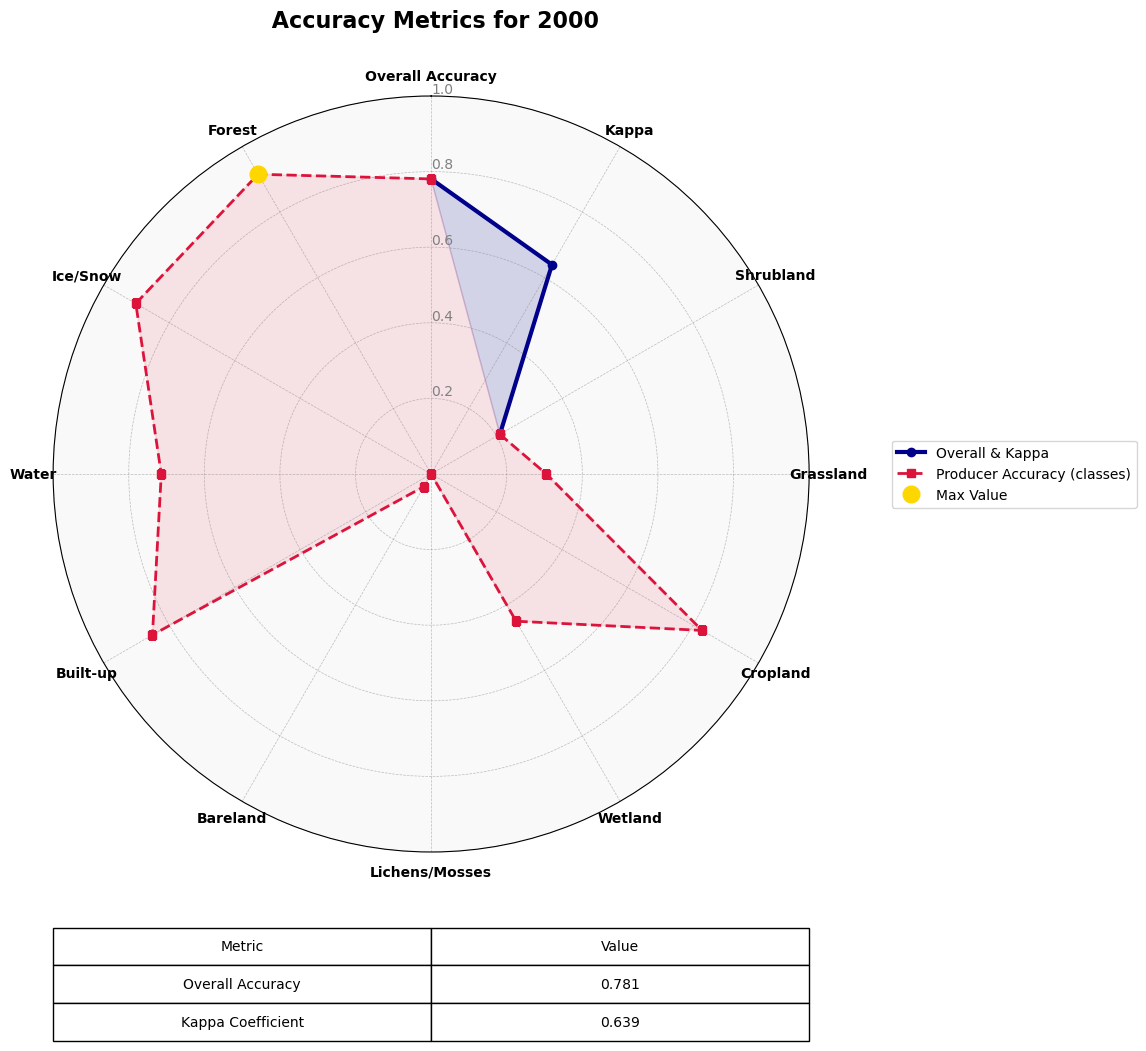

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Land cover setup ---
landcover_classes = {
    5: 'Shrubland',
    7: 'Grassland',
    8: 'Cropland',
    9: 'Wetland',
    11: 'Lichens/Mosses',
    12: 'Bareland',
    13: 'Built-up',
    15: 'Water',
    16: 'Ice/Snow',
    20: 'Forest'
}

landcover_colors = {
    5:  '#8B4513',
    7:  '#D2B48C',
    8:  '#FFA500',
    9:  '#4682B4',
    11: '#9370DB',
    12: '#A9A9A9',
    13: '#CD5C5C',
    15: '#1E90FF',
    16: '#F0FFFF',
    20: '#228B22'
}

# --- Radar plot for a given year ---
year_to_plot = 2000

# Filter class metrics and make a copy to avoid SettingWithCopyWarning
cls_metrics_year = class_metrics_df[class_metrics_df['Year'] == year_to_plot].copy()
cls_metrics_year['Order'] = cls_metrics_year['Class'].map({v:k for k,v in landcover_classes.items()})
cls_metrics_year = cls_metrics_year.sort_values('Order')

# Labels and metrics
labels = ['Overall Accuracy', 'Kappa'] + cls_metrics_year['Class'].tolist()
producer_accs = cls_metrics_year['Producer Accuracy'].tolist()
overall_acc = summary_df.loc[summary_df['Year']==year_to_plot, 'Overall Accuracy'].values[0]
kappa = summary_df.loc[summary_df['Year']==year_to_plot, 'Kappa Coefficient'].values[0]
metrics = [overall_acc, kappa] + producer_accs

# Close the radar
metrics += metrics[:1]
num_vars = len(metrics)-1
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12,12), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Axes and labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
ax.set_rlabel_position(0)
ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], color='grey', size=10)
ax.set_ylim(0,1)

# Plot overall & kappa
ax.plot(angles[:3], metrics[:3], color='darkblue', linewidth=3, marker='o', label='Overall & Kappa')
ax.fill(angles[:3], metrics[:3], color='darkblue', alpha=0.15)

# Plot class producer accuracies
ax.plot(angles[2:], metrics[2:], color='crimson', linewidth=2, linestyle='--', marker='s', label='Producer Accuracy (classes)')
ax.fill(angles[2:], metrics[2:], color='crimson', alpha=0.1)

# Highlight max value
max_idx = np.argmax(metrics)
ax.plot(angles[max_idx], metrics[max_idx], 'o', color='gold', markersize=12, label='Max Value')

# Title
plt.title(f' Accuracy Metrics for {year_to_plot}', size=16, fontweight='bold', y=1.08)

# Legend on the right
ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=10)

# Grid & background
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_facecolor('#f9f9f9')

# --- Add table under the radar ---
cell_text = [
    ['Overall Accuracy', f"{overall_acc:.3f}"],
    ['Kappa Coefficient', f"{kappa:.3f}"]
]
table = plt.table(cellText=cell_text,
                  colLabels=['Metric', 'Value'],
                  cellLoc='center',
                  loc='bottom',
                  bbox=[0.0, -0.25, 1, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.subplots_adjust(bottom=0.25)

# Save PNG
plt.savefig(f'enhanced_accuracy_radar_with_metrics_table_{year_to_plot}.png', dpi=600, bbox_inches='tight')
plt.show()




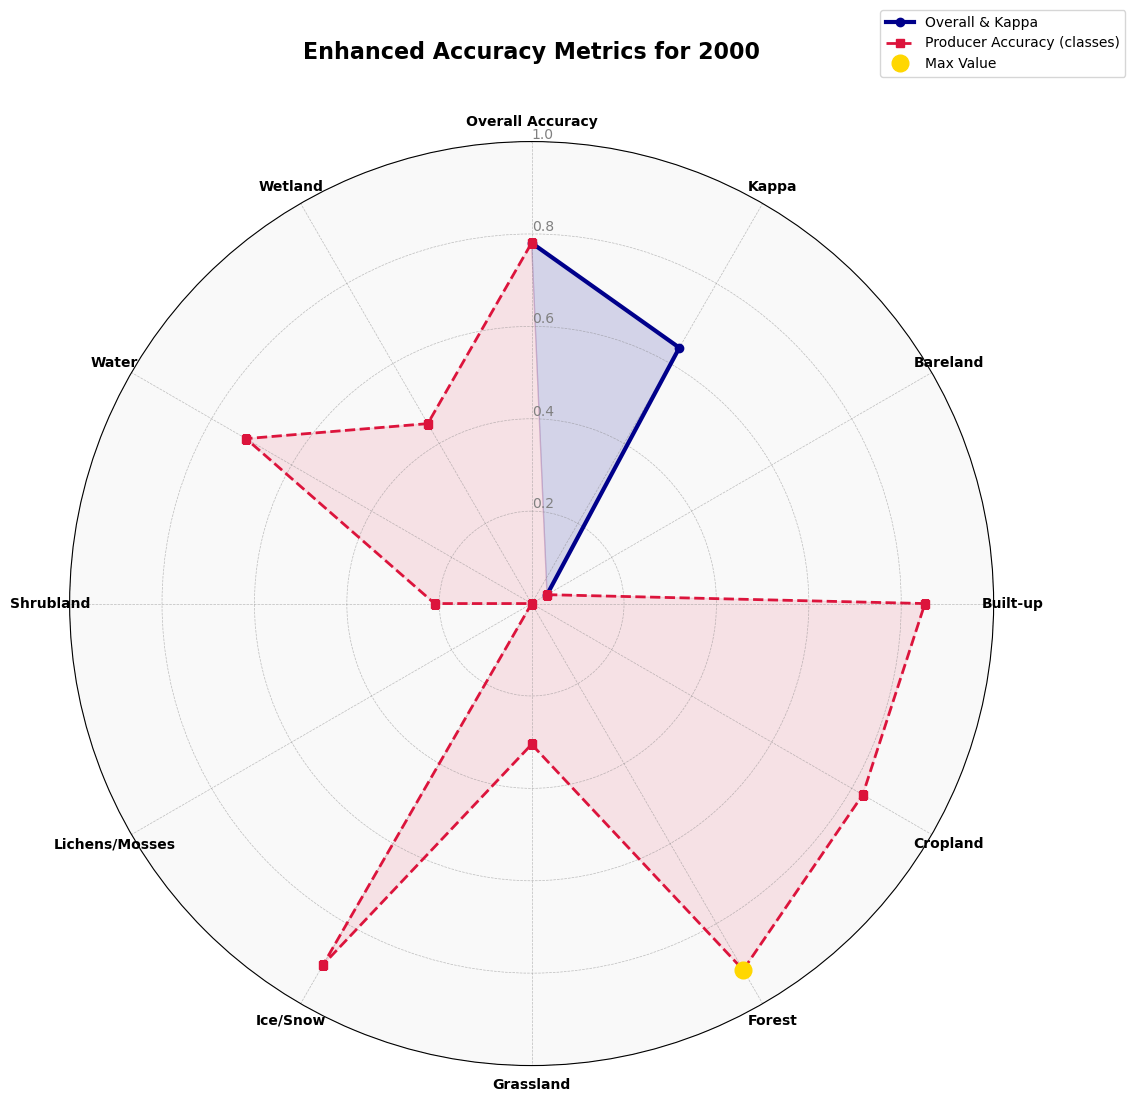

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Select the year to plot
year_to_plot = 2000

# Get overall and kappa
overall_acc = summary_df.loc[summary_df['Year']==year_to_plot, 'Overall Accuracy'].values[0]
kappa = summary_df.loc[summary_df['Year']==year_to_plot, 'Kappa Coefficient'].values[0]

# Get class-level producer accuracies for all classes in this year
cls_metrics_year = class_metrics_df[class_metrics_df['Year']==year_to_plot].sort_values('Class')
labels = ['Overall Accuracy', 'Kappa'] + cls_metrics_year['Class'].tolist()
producer_accs = cls_metrics_year['Producer Accuracy'].tolist()

# Prepare metrics array
metrics = [overall_acc, kappa] + producer_accs

# Close the radar
metrics += metrics[:1]
num_vars = len(metrics)-1
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Create figure
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

# Settings for aesthetics
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Draw axes and labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')

ax.set_rlabel_position(0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], color="grey", size=10)
ax.set_ylim(0, 1)

# Plot overall + kappa
ax.plot(angles[:3], metrics[:3], color='darkblue', linewidth=3, marker='o', label='Overall & Kappa')
ax.fill(angles[:3], metrics[:3], color='darkblue', alpha=0.15)

# Plot class producer accuracies
ax.plot(angles[2:], metrics[2:], color='crimson', linewidth=2, linestyle='--', marker='s', label='Producer Accuracy (classes)')
ax.fill(angles[2:], metrics[2:], color='crimson', alpha=0.1)

# Highlight max value
max_idx = np.argmax(metrics)
ax.plot(angles[max_idx], metrics[max_idx], 'o', color='gold', markersize=12, label='Max Value')

# Title and legend
plt.title(f'Enhanced Accuracy Metrics for {year_to_plot}', size=16, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.15), fontsize=10)

# Grid and background
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_facecolor('#f9f9f9')

# Save PNG
plt.savefig(f'enhanced_accuracy_radar_{year_to_plot}.png', dpi=600, bbox_inches='tight')
plt.show()




In [1]:
import pandas as pd
from IPython.display import display

# Paths to metrics files
metrics_files = {
    "2000": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2000/metrics_2000.txt",
    "2002": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2002/metrics_2002.txt",
    "2004": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2004/metrics_2004.txt",
    "2006": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2006/metrics_2006.txt",
    "2008": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2008/metrics_2008.txt",
    "2010": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2010/metrics_2010.txt",
    "2012": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2012/metrics_2012.txt",
    "2014": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2014/metrics_2014.txt",
    "2016": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2016/metrics_2016.txt",
    "2018": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2018/metrics_2018.txt",
    "2020": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2020/metrics_2020.txt",
    "2022": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2022/metrics_2022.txt"
}

def parse_metrics(filepath):
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    # Extract overall accuracy and kappa
    overall_accuracy = float(lines[1].split(":")[1].strip())
    kappa = float(lines[2].split(":")[1].strip())
    
    # Extract class-wise metrics
    class_metrics = []
    in_class_section = False
    for line in lines:
        if "Class-wise Metrics" in line:
            in_class_section = True
            continue
        if in_class_section:
            if ":" in line and "=" in line:
                try:
                    name, rest = line.split(":")
                    prod_str, user_str = rest.split(",")
                    producer_acc = float(prod_str.split("=")[1].replace("%", "")) / 100
                    user_acc = float(user_str.split("=")[1].replace("%", "")) / 100
                    class_metrics.append({
                        "Class": name.strip(),
                        "Producer Accuracy": producer_acc,
                        "User Accuracy": user_acc
                    })
                except Exception:
                    pass
    
    return overall_accuracy, kappa, pd.DataFrame(class_metrics)

# Display per year
for year, path in metrics_files.items():
    overall, kappa, class_df = parse_metrics(path)
    
    # Summary table
    summary_df = pd.DataFrame([{
        "Year": year,
        "Overall Accuracy": overall,
        "Kappa Coefficient": kappa
    }])
    
    # Style summary
    styled_summary = summary_df.style.format({
        "Overall Accuracy": "{:.2%}",
        "Kappa Coefficient": "{:.4f}"
    }).set_caption(f"Summary Metrics - {year}").background_gradient(cmap="YlGn")
    
    # Style class-wise metrics
    styled_classes = class_df.style.format({
        "Producer Accuracy": "{:.2%}",
        "User Accuracy": "{:.2%}"
    }).set_caption(f"Class-wise Metrics - {year}").background_gradient(cmap="Blues")
    
    display(styled_summary)
    display(styled_classes)




,Year,Overall Accuracy,Kappa Coefficient
0,2000,78.06%,0.6394


,Class,Producer Accuracy,User Accuracy
0,Shrubland,21.00%,25.27%
1,Grassland,30.48%,53.07%
2,Cropland,82.76%,88.92%
3,Wetland,44.97%,23.40%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,3.85%,69.90%
6,Built-up,85.13%,62.36%
7,Water,71.39%,91.43%
8,Ice/Snow,90.22%,32.51%
9,Forest,91.57%,71.07%


,Year,Overall Accuracy,Kappa Coefficient
0,2002,78.41%,0.6454


,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.88%,25.70%
1,Grassland,30.14%,54.03%
2,Cropland,83.09%,89.10%
3,Wetland,47.47%,24.90%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.05%,71.24%
6,Built-up,83.21%,65.35%
7,Water,71.76%,91.34%
8,Ice/Snow,90.76%,32.72%
9,Forest,92.12%,71.22%


,Year,Overall Accuracy,Kappa Coefficient
0,2004,78.68%,0.6507


...

,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.64%,26.43%
1,Grassland,29.52%,55.33%
2,Cropland,83.88%,88.52%
3,Wetland,43.14%,24.78%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.63%,70.91%
6,Built-up,77.00%,77.73%
7,Water,73.94%,89.69%
8,Ice/Snow,94.59%,30.05%
9,Forest,92.23%,71.92%


,Year,Overall Accuracy,Kappa Coefficient
0,2020,78.75%,0.6542


,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.47%,26.09%
1,Grassland,29.26%,55.03%
2,Cropland,83.69%,88.36%
3,Wetland,40.50%,24.37%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.64%,70.78%
6,Built-up,77.15%,77.44%
7,Water,74.21%,88.85%
8,Ice/Snow,93.78%,30.16%
9,Forest,91.89%,71.73%


,Year,Overall Accuracy,Kappa Coefficient
0,2022,78.77%,0.6544


,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.27%,26.46%
1,Grassland,29.07%,54.88%
2,Cropland,83.88%,88.20%
3,Wetland,41.10%,24.60%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.74%,70.51%
6,Built-up,75.84%,80.04%
7,Water,73.63%,88.74%
8,Ice/Snow,92.22%,30.37%
9,Forest,91.88%,71.60%


In [4]:
import pandas as pd
from IPython.display import display

# Paths to metrics files
metrics_files = {
    "2000": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2000/metrics_2000.txt",
    "2002": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2002/metrics_2002.txt",
    "2004": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2004/metrics_2004.txt",
    "2006": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2006/metrics_2006.txt",
    "2008": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2008/metrics_2008.txt",
    "2010": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2010/metrics_2010.txt",
    "2012": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2012/metrics_2012.txt",
    "2014": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2014/metrics_2014.txt",
    "2016": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2016/metrics_2016.txt",
    "2018": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2018/metrics_2018.txt",
    "2020": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2020/metrics_2020.txt",
    "2022": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2022/metrics_2022.txt"
}

def parse_metrics(filepath):
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    # Extract overall accuracy and kappa
    overall_accuracy = float(lines[1].split(":")[1].strip())
    kappa = float(lines[2].split(":")[1].strip())
    
    # Extract class-wise metrics
    class_metrics = []
    in_class_section = False
    for line in lines:
        if "Class-wise Metrics" in line:
            in_class_section = True
            continue
        if in_class_section:
            if ":" in line and "=" in line:
                try:
                    name, rest = line.split(":")
                    prod_str, user_str = rest.split(",")
                    producer_acc = float(prod_str.split("=")[1].replace("%", "")) / 100
                    user_acc = float(user_str.split("=")[1].replace("%", "")) / 100
                    class_metrics.append({
                        "Class": name.strip(),
                        "Producer Accuracy": producer_acc,
                        "User Accuracy": user_acc
                    })
                except Exception:
                    pass
    
    # Extract confusion matrix
    confusion_labels = []
    confusion_data = []
    in_confusion_section = False
    for line in lines:
        if "Confusion Matrix" in line:
            in_confusion_section = True
            continue
        if in_confusion_section:
            parts = line.split()
            if not confusion_labels:
                confusion_labels = parts
                # Drop the "Class" column if it exists
                if confusion_labels[0].lower() in ["class", "classes", ""]:
                    confusion_labels = confusion_labels[1:]
            else:
                row_label = parts[0]
                values = [int(x) for x in parts[1:]]
                confusion_data.append((row_label, values))
    
    # Build confusion matrix DataFrame safely
    if confusion_labels and confusion_data:
        index_labels = []
        matrix_values = []
        
        for row_label, row_values in confusion_data:
            if len(row_values) == len(confusion_labels):
                index_labels.append(row_label)
                matrix_values.append(row_values)
            elif len(row_values) < len(confusion_labels):
                # Pad missing values with zeros
                index_labels.append(row_label)
                matrix_values.append(row_values + [0] * (len(confusion_labels) - len(row_values)))
            else:
                # Trim extra values
                index_labels.append(row_label)
                matrix_values.append(row_values[:len(confusion_labels)])
        
        confusion_df = pd.DataFrame(matrix_values, columns=confusion_labels, index=index_labels)
    else:
        confusion_df = pd.DataFrame()

    return overall_accuracy, kappa, pd.DataFrame(class_metrics), confusion_df

# Display per year
for year, path in metrics_files.items():
    overall, kappa, class_df, confusion_df = parse_metrics(path)
    
    # Summary table
    summary_df = pd.DataFrame([{
        "Year": year,
        "Overall Accuracy": overall,
        "Kappa Coefficient": kappa
    }])
    
    styled_summary = summary_df.style.format({
        "Overall Accuracy": "{:.2%}",
        "Kappa Coefficient": "{:.4f}"
    }).set_caption(f"Summary Metrics - {year}").background_gradient(cmap="YlGn")
    
    # Class-wise metrics table
    styled_classes = class_df.style.format({
        "Producer Accuracy": "{:.2%}",
        "User Accuracy": "{:.2%}"
    }).set_caption(f"Class-wise Metrics - {year}").background_gradient(cmap="Blues")
    
    # Confusion matrix table
    if not confusion_df.empty:
        styled_confusion = confusion_df.style.set_caption(f"Confusion Matrix - {year}").background_gradient(cmap="OrRd")
    else:
        styled_confusion = "No confusion matrix found."
    
    display(styled_summary)
    display(styled_classes)
    if isinstance(styled_confusion, str):
        print(styled_confusion)
    else:
        display(styled_confusion)


,Year,Overall Accuracy,Kappa Coefficient
0,2000,78.06%,0.6394


,Class,Producer Accuracy,User Accuracy
0,Shrubland,21.00%,25.27%
1,Grassland,30.48%,53.07%
2,Cropland,82.76%,88.92%
3,Wetland,44.97%,23.40%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,3.85%,69.90%
6,Built-up,85.13%,62.36%
7,Water,71.39%,91.43%
8,Ice/Snow,90.22%,32.51%
9,Forest,91.57%,71.07%


,19116,4981,7827,187,4,509,492,126,366,57399
19417,65575,71048,62,5,523,1434,142,280,56674,0
16768,34183,1509631,906,1,17,24360,466,85,237742,0
42,4,770,1742,0,235,126,357,0,598,0
0,0,0,0,0,0,0,0,0,0,0
12098,1212,39137,353,1,3499,16553,1015,6413,10544,0
38,26,12492,51,0,3,80172,112,0,1285,0
250,46,3954,3516,0,3,2008,30151,2,2303,0
69,4,5,0,0,186,0,81,3468,31,0
7857,17538,52820,626,1,31,3425,527,55,900652,0


,Year,Overall Accuracy,Kappa Coefficient
0,2002,78.41%,0.6454


,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.88%,25.70%
1,Grassland,30.14%,54.03%
2,Cropland,83.09%,89.10%
3,Wetland,47.47%,24.90%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.05%,71.24%
6,Built-up,83.21%,65.35%
7,Water,71.76%,91.34%
8,Ice/Snow,90.76%,32.72%
9,Forest,92.12%,71.22%


...

,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.47%,26.09%
1,Grassland,29.26%,55.03%
2,Cropland,83.69%,88.36%
3,Wetland,40.50%,24.37%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.64%,70.78%
6,Built-up,77.15%,77.44%
7,Water,74.21%,88.85%
8,Ice/Snow,93.78%,30.16%
9,Forest,91.89%,71.73%


,18978,4799,7720,152,1,494,447,202,590,59330
19276,63188,72628,53,0,521,1076,221,419,58536,0
14382,30106,1493519,871,0,7,20712,746,87,224072,0
26,5,669,1588,0,180,88,721,0,644,0
0,0,0,0,0,0,0,0,0,0,0
11510,1198,28058,316,0,3260,7605,1016,7169,10148,0
145,101,30567,70,0,1,114792,235,0,2879,0
199,40,3735,2860,0,3,1817,30779,3,2041,0
55,5,4,0,0,117,0,34,3605,24,0
8178,15387,53377,606,1,23,1688,687,80,907341,0


,Year,Overall Accuracy,Kappa Coefficient
0,2022,78.77%,0.6544


,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.27%,26.46%
1,Grassland,29.07%,54.88%
2,Cropland,83.88%,88.20%
3,Wetland,41.10%,24.60%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.74%,70.51%
6,Built-up,75.84%,80.04%
7,Water,73.63%,88.74%
8,Ice/Snow,92.22%,30.37%
9,Forest,91.88%,71.60%


,18933,4791,7736,161,1,495,387,207,565,60148
18984,62589,72921,47,0,521,947,221,384,58696,0
13715,29795,1495826,879,0,10,17813,726,88,224492,0
24,4,668,1619,0,171,104,689,0,660,0
0,0,0,0,0,0,0,0,0,0,0
11340,1174,28095,294,0,3264,6312,1121,7014,10292,0
150,86,33382,69,0,1,115772,230,0,2963,0
241,42,3836,2932,0,3,1784,30536,4,2093,0
67,5,4,0,0,143,0,54,3545,26,0
8087,15556,53557,581,1,21,1528,628,73,905890,0


,Year,Overall Accuracy,Kappa Coefficient
0,2000,78.06%,0.6394


,Class,Producer Accuracy,User Accuracy
0,Shrubland,21.00%,25.27%
1,Grassland,30.48%,53.07%
2,Cropland,82.76%,88.92%
3,Wetland,44.97%,23.40%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,3.85%,69.90%
6,Built-up,85.13%,62.36%
7,Water,71.39%,91.43%
8,Ice/Snow,90.22%,32.51%
9,Forest,91.57%,71.07%


,19116,4981,7827,187,4,509,492,126,366,57399
19417,65575,71048,62,5,523,1434,142,280,56674,0
16768,34183,1509631,906,1,17,24360,466,85,237742,0
42,4,770,1742,0,235,126,357,0,598,0
0,0,0,0,0,0,0,0,0,0,0
12098,1212,39137,353,1,3499,16553,1015,6413,10544,0
38,26,12492,51,0,3,80172,112,0,1285,0
250,46,3954,3516,0,3,2008,30151,2,2303,0
69,4,5,0,0,186,0,81,3468,31,0
7857,17538,52820,626,1,31,3425,527,55,900652,0


,Year,Overall Accuracy,Kappa Coefficient
0,2002,78.41%,0.6454


,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.88%,25.70%
1,Grassland,30.14%,54.03%
2,Cropland,83.09%,89.10%
3,Wetland,47.47%,24.90%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.05%,71.24%
6,Built-up,83.21%,65.35%
7,Water,71.76%,91.34%
8,Ice/Snow,90.76%,32.72%
9,Forest,92.12%,71.22%


...

,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.47%,26.09%
1,Grassland,29.26%,55.03%
2,Cropland,83.69%,88.36%
3,Wetland,40.50%,24.37%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.64%,70.78%
6,Built-up,77.15%,77.44%
7,Water,74.21%,88.85%
8,Ice/Snow,93.78%,30.16%
9,Forest,91.89%,71.73%


,18978,4799,7720,152,1,494,447,202,590,59330
19276,63188,72628,53,0,521,1076,221,419,58536,0
14382,30106,1493519,871,0,7,20712,746,87,224072,0
26,5,669,1588,0,180,88,721,0,644,0
0,0,0,0,0,0,0,0,0,0,0
11510,1198,28058,316,0,3260,7605,1016,7169,10148,0
145,101,30567,70,0,1,114792,235,0,2879,0
199,40,3735,2860,0,3,1817,30779,3,2041,0
55,5,4,0,0,117,0,34,3605,24,0
8178,15387,53377,606,1,23,1688,687,80,907341,0


,Year,Overall Accuracy,Kappa Coefficient
0,2022,78.77%,0.6544


,Class,Producer Accuracy,User Accuracy
0,Shrubland,20.27%,26.46%
1,Grassland,29.07%,54.88%
2,Cropland,83.88%,88.20%
3,Wetland,41.10%,24.60%
4,Lichens/Mosses,0.00%,0.00%
5,Bareland,4.74%,70.51%
6,Built-up,75.84%,80.04%
7,Water,73.63%,88.74%
8,Ice/Snow,92.22%,30.37%
9,Forest,91.88%,71.60%


,18933,4791,7736,161,1,495,387,207,565,60148
18984,62589,72921,47,0,521,947,221,384,58696,0
13715,29795,1495826,879,0,10,17813,726,88,224492,0
24,4,668,1619,0,171,104,689,0,660,0
0,0,0,0,0,0,0,0,0,0,0
11340,1174,28095,294,0,3264,6312,1121,7014,10292,0
150,86,33382,69,0,1,115772,230,0,2963,0
241,42,3836,2932,0,3,1784,30536,4,2093,0
67,5,4,0,0,143,0,54,3545,26,0
8087,15556,53557,581,1,21,1528,628,73,905890,0


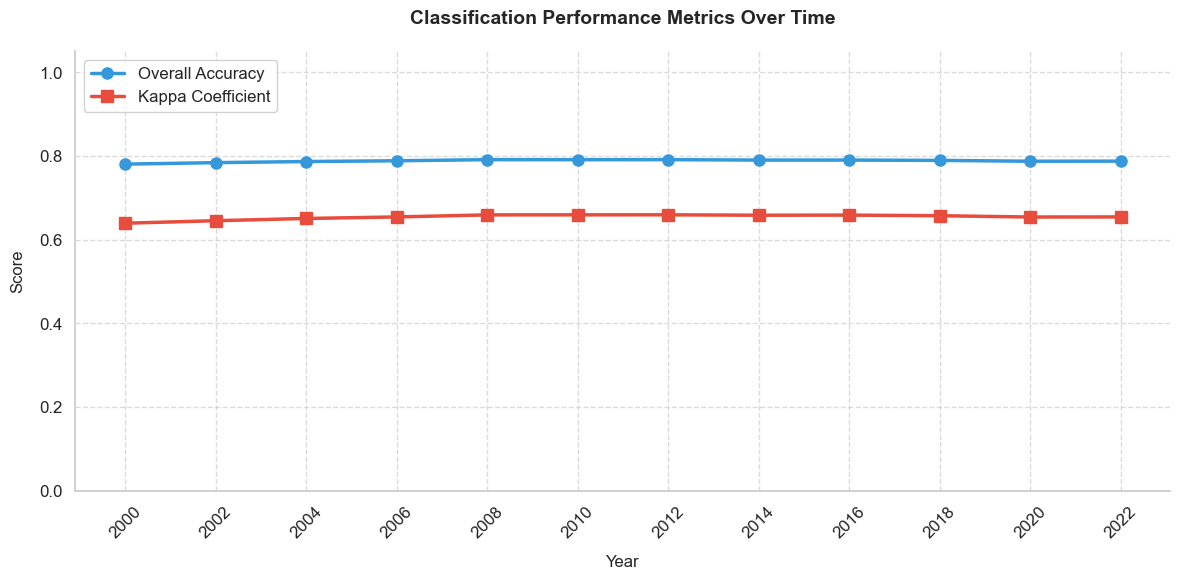

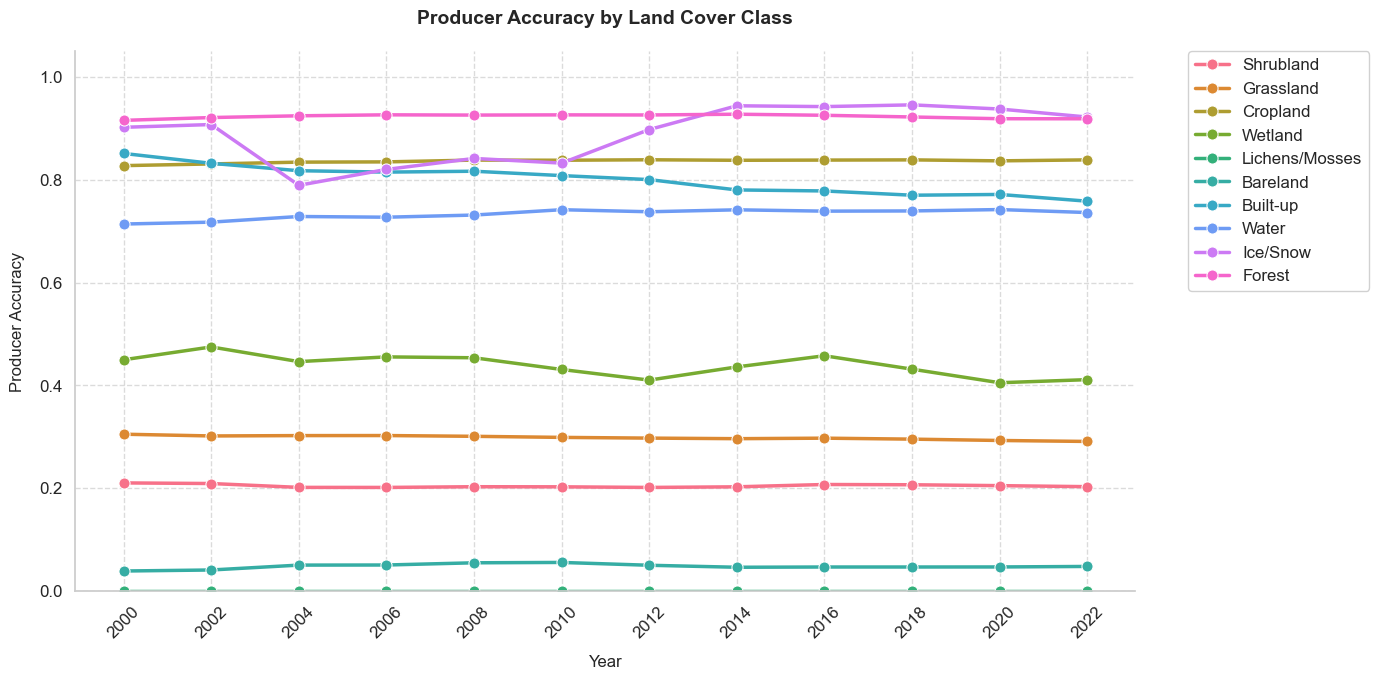

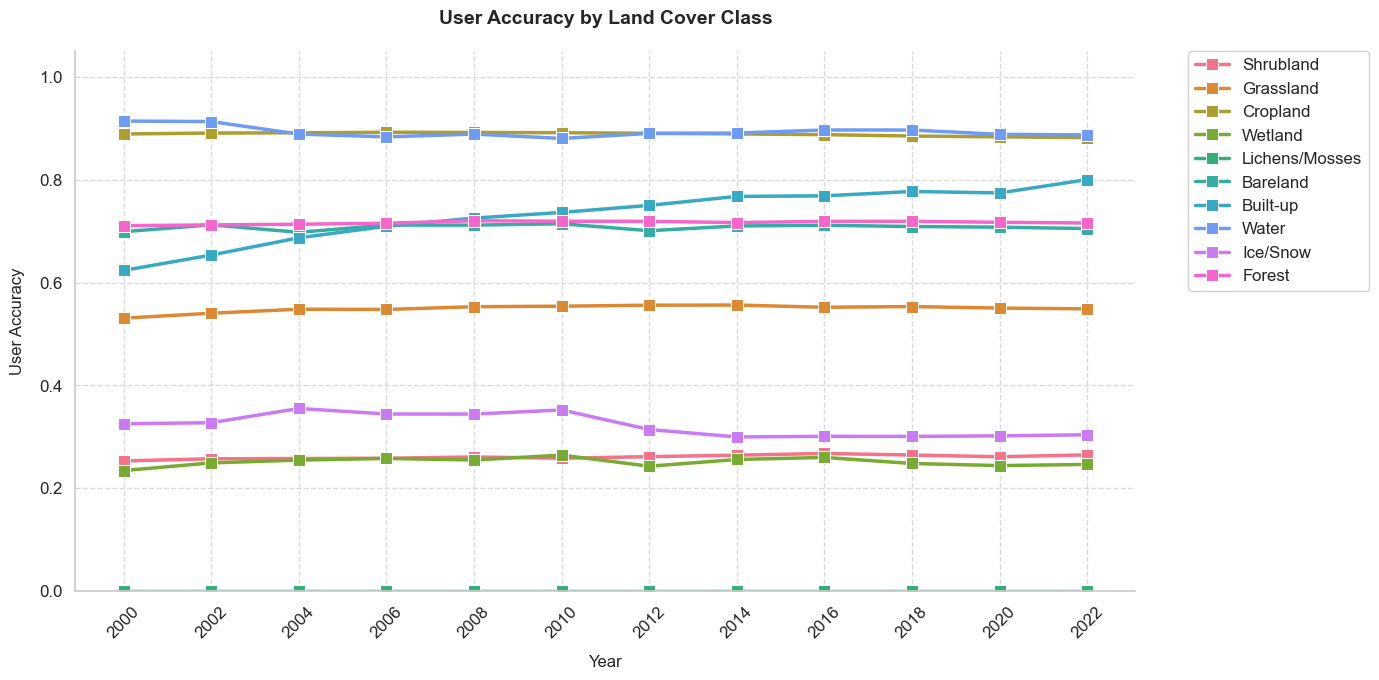

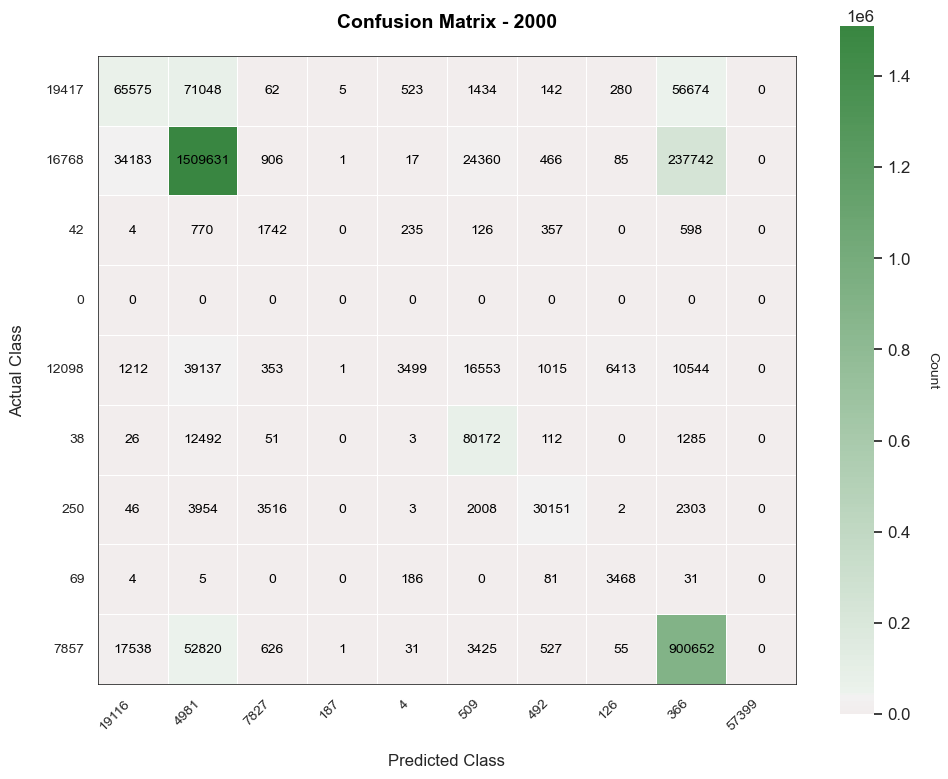

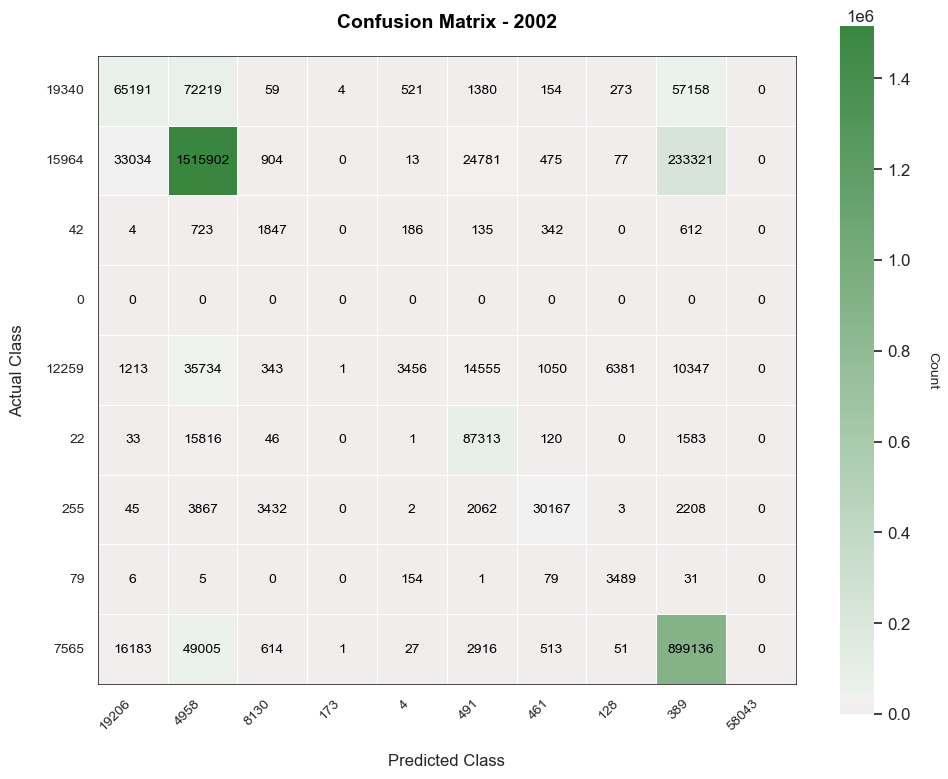

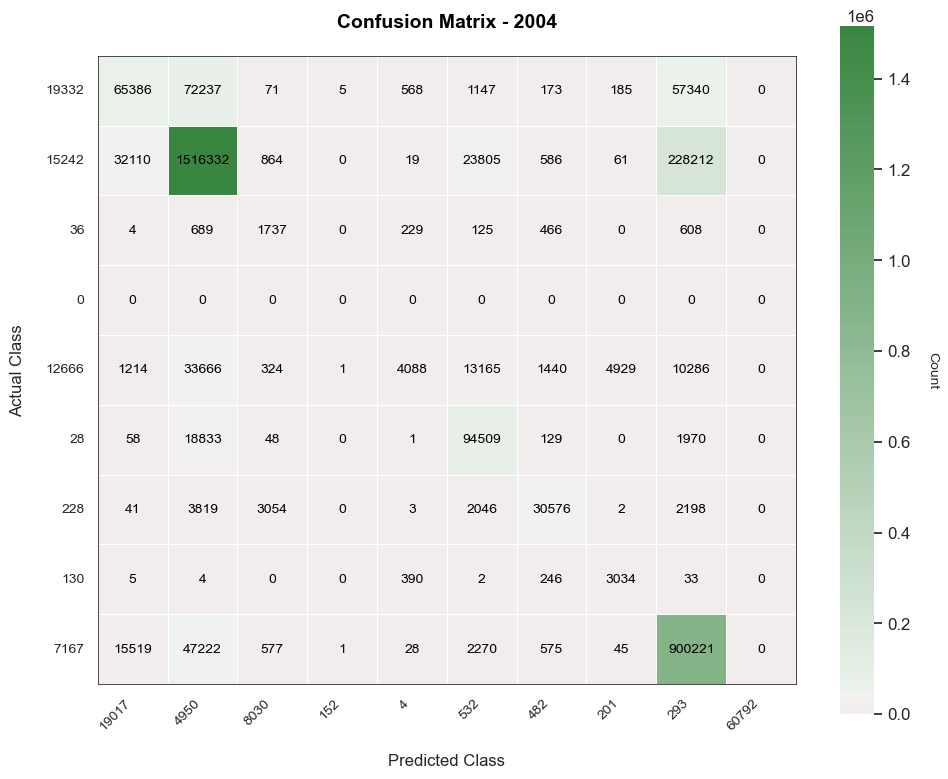

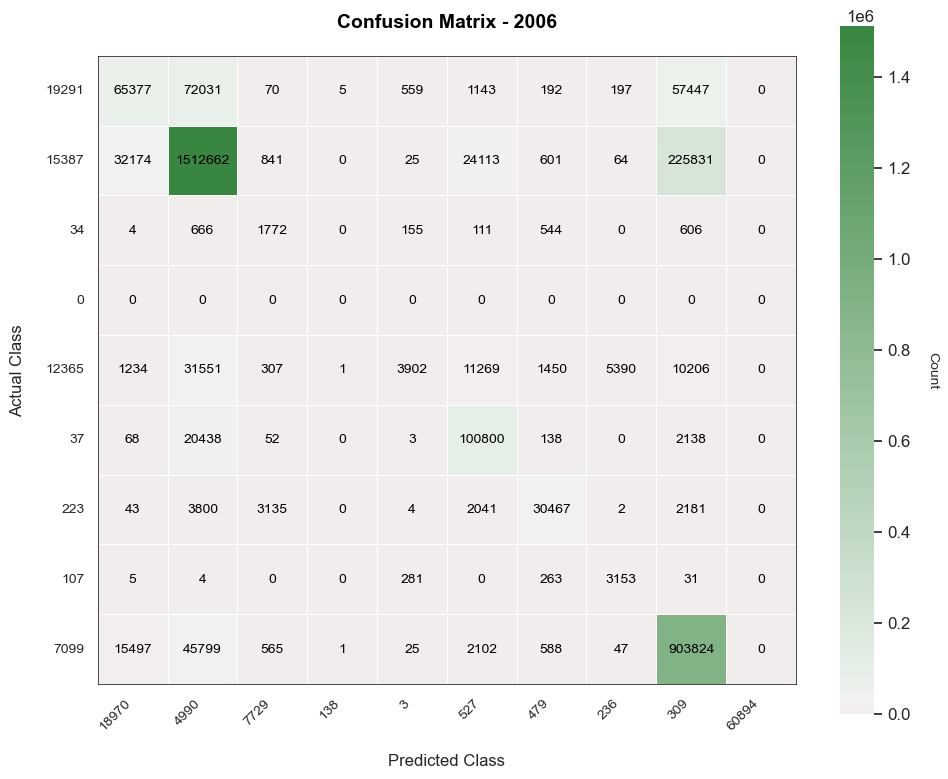

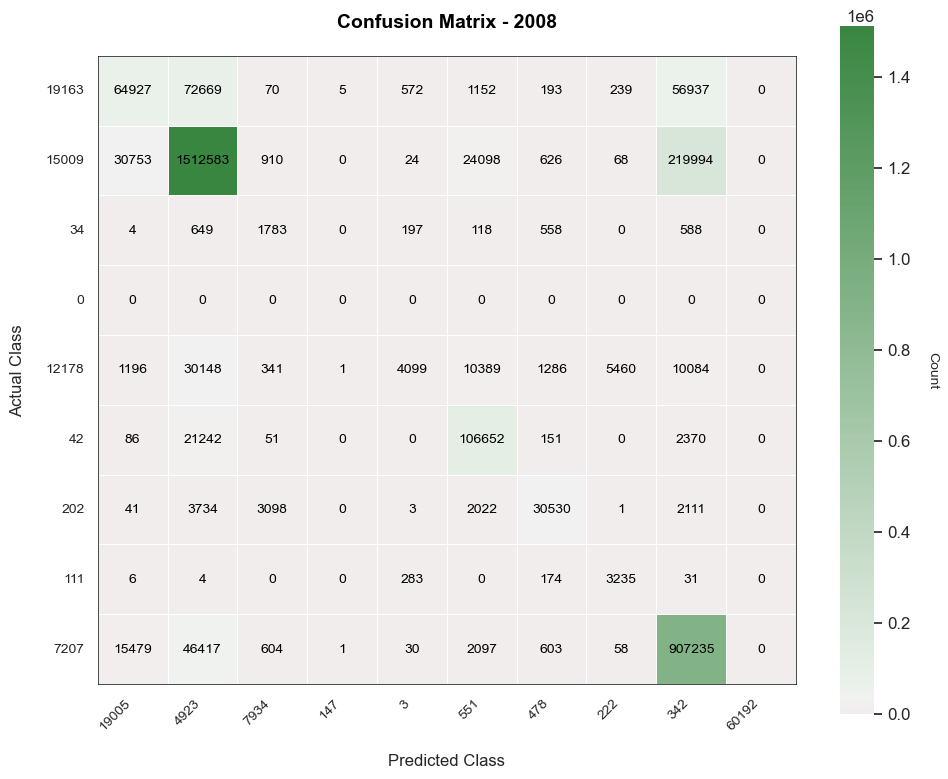

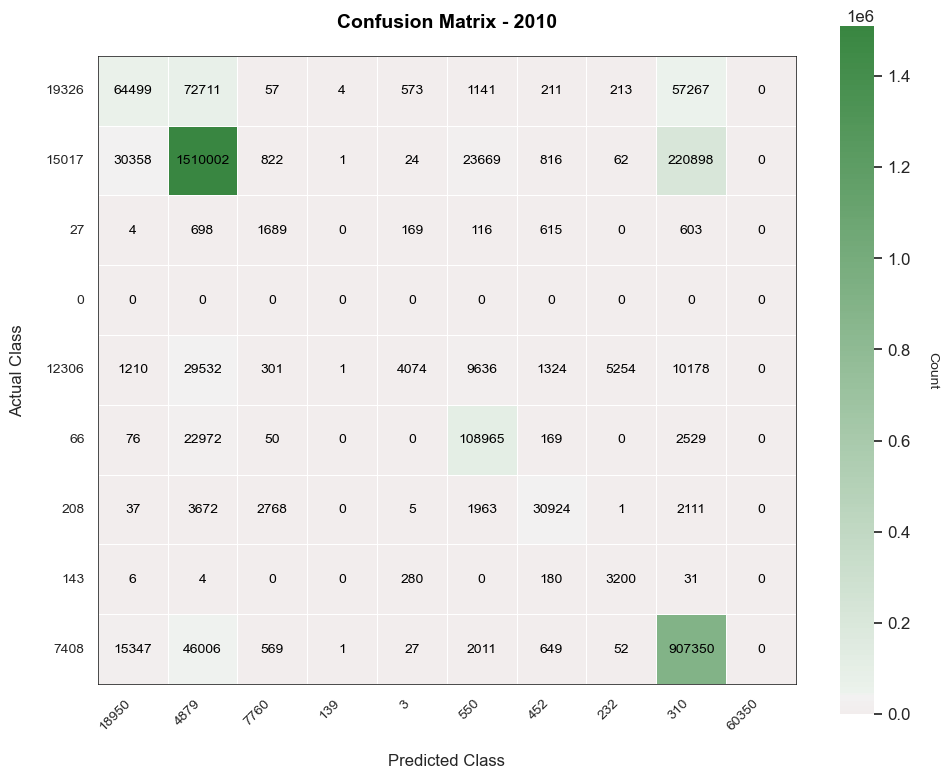

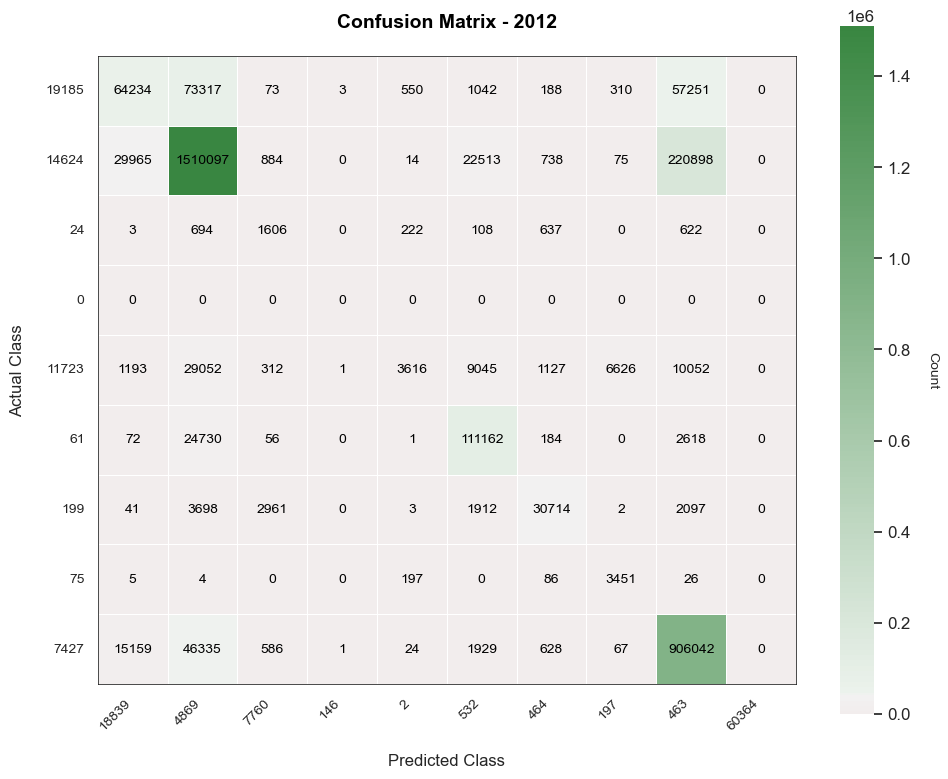

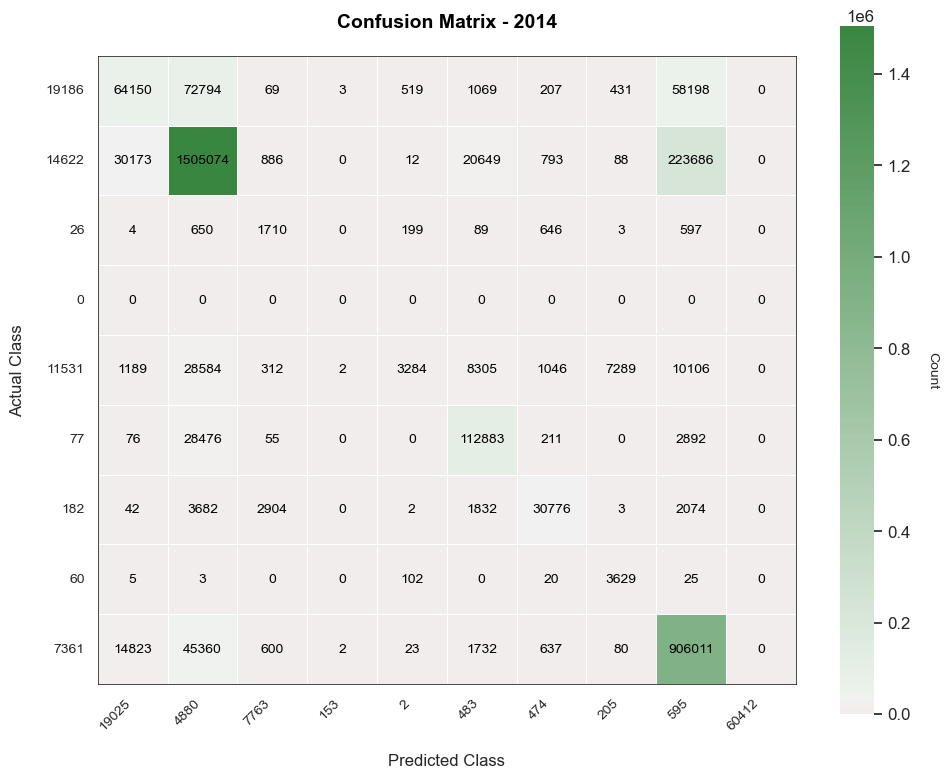

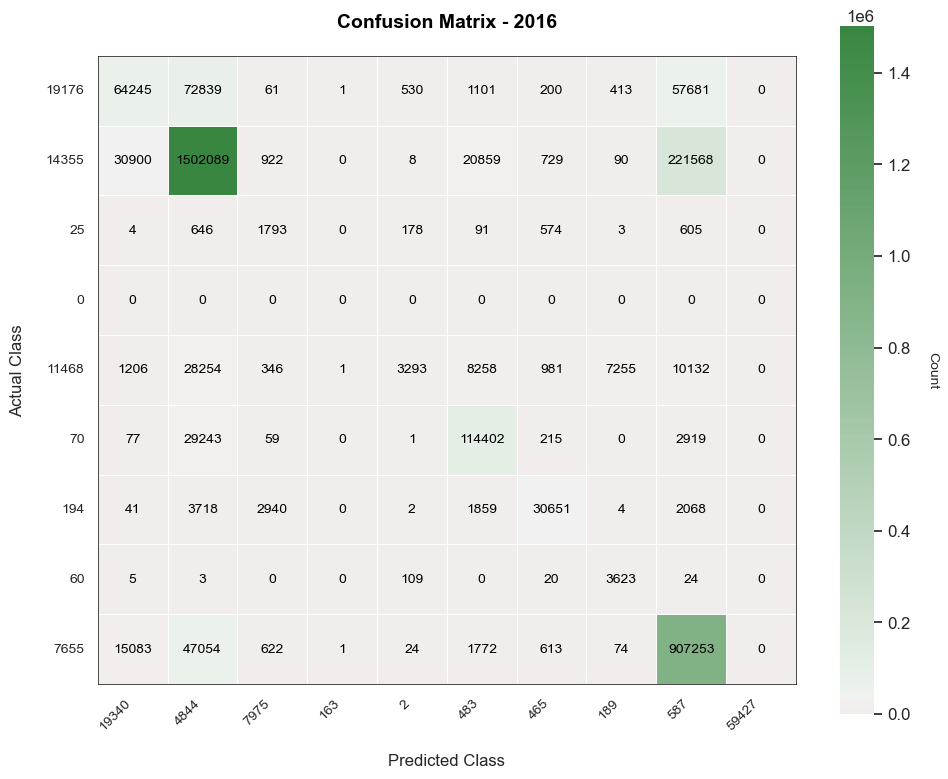

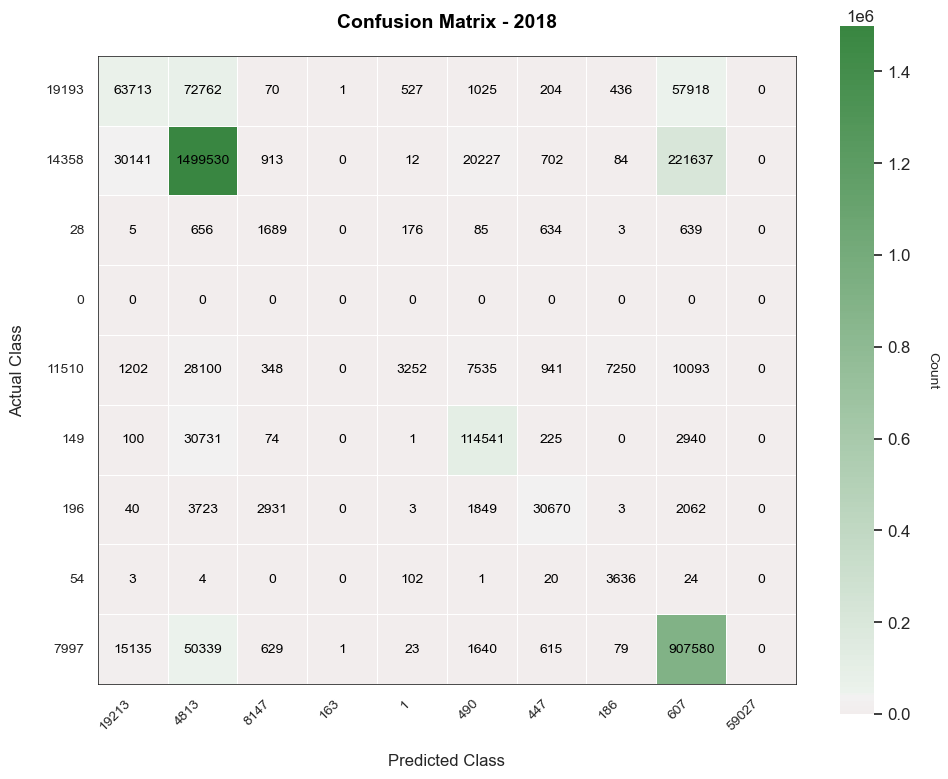

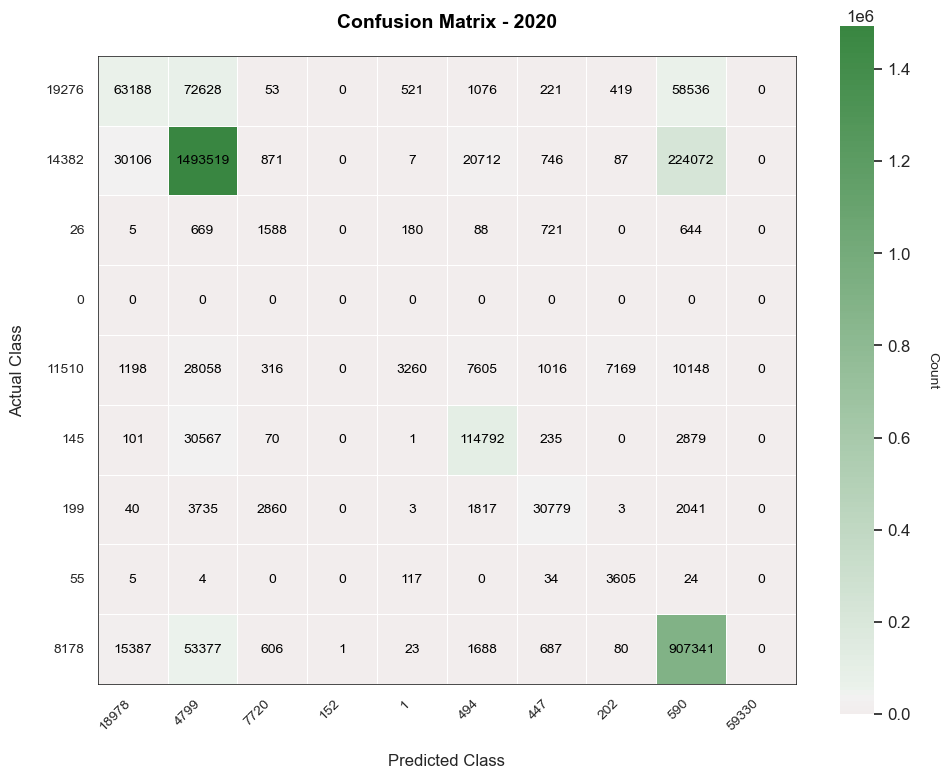

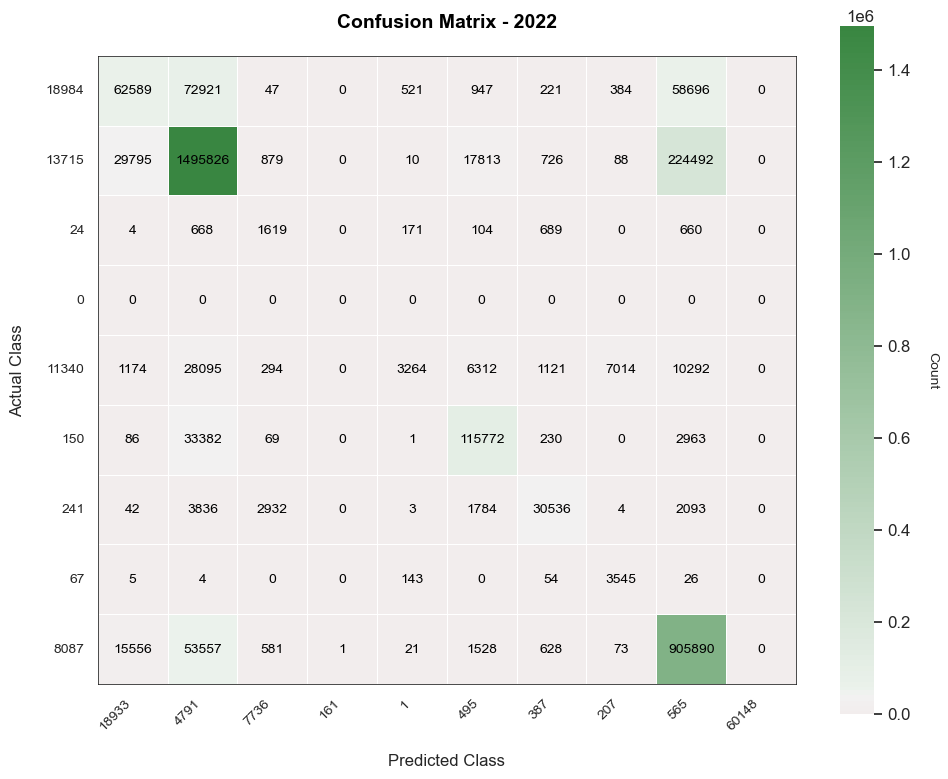

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

# Set global style parameters
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'

# Paths to metrics files
metrics_files = {
    "2000": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2000/metrics_2000.txt",
    "2002": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2002/metrics_2002.txt",
    "2004": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2004/metrics_2004.txt",
    "2006": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2006/metrics_2006.txt",
    "2008": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2008/metrics_2008.txt",
    "2010": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2010/metrics_2010.txt",
    "2012": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2012/metrics_2012.txt",
    "2014": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2014/metrics_2014.txt",
    "2016": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2016/metrics_2016.txt",
    "2018": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2018/metrics_2018.txt",
    "2020": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2020/metrics_2020.txt",
    "2022": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2022/metrics_2022.txt"
}

# Function to parse metrics from .txt
def parse_metrics(filepath):
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    # Overall accuracy and Kappa
    overall_accuracy = float(lines[1].split(":")[1].strip())
    kappa = float(lines[2].split(":")[1].strip())
    
    # Class-wise metrics
    class_metrics = []
    in_class_section = False
    for line in lines:
        if "Class-wise Metrics" in line:
            in_class_section = True
            continue
        if in_class_section and ":" in line and "=" in line:
            try:
                name, rest = line.split(":")
                prod_str, user_str = rest.split(",")
                producer_acc = float(prod_str.split("=")[1].replace("%", "")) / 100
                user_acc = float(user_str.split("=")[1].replace("%", "")) / 100
                class_metrics.append({
                    "Class": name.strip(),
                    "Producer Accuracy": producer_acc,
                    "User Accuracy": user_acc
                })
            except Exception:
                pass
    
    # Confusion matrix
    confusion_labels = []
    confusion_data = []
    in_confusion_section = False
    for line in lines:
        if "Confusion Matrix" in line:
            in_confusion_section = True
            continue
        if in_confusion_section:
            parts = line.split()
            if not confusion_labels:
                confusion_labels = parts
                if confusion_labels[0].lower() in ["class", "classes", ""]:
                    confusion_labels = confusion_labels[1:]
            else:
                row_label = parts[0]
                values = [int(x) for x in parts[1:]]
                confusion_data.append((row_label, values))
    
    if confusion_labels and confusion_data:
        index_labels = []
        matrix_values = []
        for row_label, row_values in confusion_data:
            if len(row_values) == len(confusion_labels):
                index_labels.append(row_label)
                matrix_values.append(row_values)
            elif len(row_values) < len(confusion_labels):
                index_labels.append(row_label)
                matrix_values.append(row_values + [0] * (len(confusion_labels) - len(row_values)))
            else:
                index_labels.append(row_label)
                matrix_values.append(row_values[:len(confusion_labels)])
        confusion_df = pd.DataFrame(matrix_values, columns=confusion_labels, index=index_labels)
    else:
        confusion_df = pd.DataFrame()

    return overall_accuracy, kappa, pd.DataFrame(class_metrics), confusion_df

# Store metrics for plotting
years = []
overall_acc = []
kappa_coeff = []
pa_records = []  # Producer Accuracy
ua_records = []  # User Accuracy
conf_mats = {}   # Confusion matrices

for year, path in metrics_files.items():
    overall, kappa, class_df, confusion_df = parse_metrics(path)
    
    years.append(int(year))
    overall_acc.append(overall)
    kappa_coeff.append(kappa)
    
    for _, row in class_df.iterrows():
        pa_records.append({"Year": int(year), "Class": row["Class"], "Value": row["Producer Accuracy"]})
        ua_records.append({"Year": int(year), "Class": row["Class"], "Value": row["User Accuracy"]})
    
    if not confusion_df.empty:
        conf_mats[int(year)] = confusion_df
    
    # Display tables with improved styling
    summary_df = pd.DataFrame([{"Year": year, "Overall Accuracy": overall, "Kappa Coefficient": kappa}])
    styled_summary = (summary_df.style
                     .format({"Overall Accuracy": "{:.2%}", "Kappa Coefficient": "{:.4f}"})
                     .set_caption(f"Summary Metrics - {year}")
                     .background_gradient(cmap="YlGn", subset=['Overall Accuracy', 'Kappa Coefficient'])
                     .set_properties(**{'text-align': 'center'}))
    
    styled_classes = (class_df.style
                     .format({"Producer Accuracy": "{:.2%}", "User Accuracy": "{:.2%}"})
                     .set_caption(f"Class-wise Metrics - {year}")
                     .background_gradient(cmap="Blues", subset=['Producer Accuracy', 'User Accuracy'])
                     .set_properties(**{'text-align': 'center'}))
    
    display(styled_summary)
    display(styled_classes)
    if confusion_df.empty:
        print(f"No confusion matrix found for {year}")
    else:
        display(confusion_df.style.set_caption(f"Confusion Matrix - {year}")
               .background_gradient(cmap="OrRd").set_properties(**{'text-align': 'center'}))

# Convert class-wise accuracies to DataFrame
pa_df = pd.DataFrame(pa_records)
ua_df = pd.DataFrame(ua_records)

# ----------------- Plotting -----------------
# Custom color palette
custom_palette = sns.color_palette("husl", len(pa_df['Class'].unique()))

# Plot Overall Accuracy and Kappa
plt.figure(figsize=(12, 6))
plt.plot(years, overall_acc, marker='o', markersize=8, linewidth=2.5, 
         color='#3498db', label="Overall Accuracy")
plt.plot(years, kappa_coeff, marker='s', markersize=8, linewidth=2.5, 
         color='#e74c3c', label="Kappa Coefficient")

plt.title("Classification Performance Metrics Over Time", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("Score", fontsize=12, labelpad=10)
plt.ylim(0, 1.05)
plt.xticks(years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', frameon=True, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

# Plot Producer Accuracy per class
plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=pa_df, x="Year", y="Value", hue="Class", 
                 palette=custom_palette, marker="o", markersize=8, 
                 linewidth=2.5, style="Class", dashes=False)

plt.title("Producer Accuracy by Land Cover Class", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("Producer Accuracy", fontsize=12, labelpad=10)
plt.ylim(0, 1.05)
plt.xticks(years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, 
           frameon=True, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

# Plot User Accuracy per class
plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=ua_df, x="Year", y="Value", hue="Class", 
                 palette=custom_palette, marker="s", markersize=8, 
                 linewidth=2.5, style="Class", dashes=False)

plt.title("User Accuracy by Land Cover Class", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("User Accuracy", fontsize=12, labelpad=10)
plt.ylim(0, 1.05)
plt.xticks(years, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, 
           frameon=True, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

# ----------------- Professional Confusion Matrix Heatmaps -----------------
for year, conf_df in conf_mats.items():
    plt.figure(figsize=(10, 8))
    
    # Create a mask for the upper triangle if square matrix
    mask = None
    if conf_df.shape[0] == conf_df.shape[1]:
        mask = np.zeros_like(conf_df, dtype=bool)
        mask[np.triu_indices_from(mask)] = True
    
    # Custom diverging color map
    cmap = sns.diverging_palette(10, 130, as_cmap=True)
    
    # Create heatmap with professional styling
    ax = sns.heatmap(
        conf_df, 
        annot=True, 
        fmt='d', 
        cmap=cmap,
        cbar=True,
        mask=mask,
        linewidths=0.5,
        linecolor='white',
        annot_kws={
            'fontsize': 10,
            'fontweight': 'normal',
            'color': 'black'
        },
        square=True,
        center=conf_df.values.mean() if not mask else None
    )
    
    # Customize colorbar
    cbar = ax.collections[0].colorbar
    cbar.set_label('Count', rotation=270, labelpad=20, fontsize=10)
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    # Add title and labels with professional styling
    plt.title(
        f"Confusion Matrix - {year}", 
        pad=20, 
        fontdict={
            'fontsize': 14,
            'fontweight': 'bold',
            'color': 'black'
        }
    )
    plt.xlabel(
        "Predicted Class", 
        labelpad=15, 
        fontdict={
            'fontsize': 12,
            'fontweight': 'medium'
        }
    )
    plt.ylabel(
        "Actual Class", 
        labelpad=15, 
        fontdict={
            'fontsize': 12,
            'fontweight': 'medium'
        }
    )
    
    # Add border
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)
    
    plt.tight_layout()
    plt.show()


    

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import re
from pathlib import Path

# Set output directory for thesis materials
output_dir = "/Users/ghulamabbaszafari/Downloads/thesis_landcover_analysis"
os.makedirs(output_dir, exist_ok=True)

# Set global style parameters
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['savefig.dpi'] = 300  # High resolution for thesis
plt.rcParams['savefig.bbox'] = 'tight'

# Paths to metrics files
metrics_files = {
    "2000": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2000/metrics_2000.txt",
    "2002": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2002/metrics_2002.txt",
    "2004": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2004/metrics_2004.txt",
    "2006": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2006/metrics_2006.txt",
    "2008": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2008/metrics_2008.txt",
    "2010": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2010/metrics_2010.txt",
    "2012": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2012/metrics_2012.txt",
    "2014": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2014/metrics_2014.txt",
    "2016": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2016/metrics_2016.txt",
    "2018": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2018/metrics_2018.txt",
    "2020": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2020/metrics_2020.txt",
    "2022": "/Users/ghulamabbaszafari/Downloads/landcover_comparison_results1/2022/metrics_2022.txt"
}

# Function to sanitize filenames
def sanitize_filename(name):
    """Remove or replace characters that are not safe for filenames"""
    # Replace problematic characters with underscores
    name = re.sub(r'[/\\:*?"<>|]', '_', name)
    # Replace spaces with underscores
    name = name.replace(' ', '_')
    # Remove any other non-alphanumeric characters (except underscores and hyphens)
    name = re.sub(r'[^a-zA-Z0-9_-]', '', name)
    return name.lower()

# Function to parse metrics from .txt
def parse_metrics(filepath):
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    # Overall accuracy and Kappa
    overall_accuracy = float(lines[1].split(":")[1].strip())
    kappa = float(lines[2].split(":")[1].strip())
    
    # Class-wise metrics
    class_metrics = []
    in_class_section = False
    for line in lines:
        if "Class-wise Metrics" in line:
            in_class_section = True
            continue
        if in_class_section and ":" in line and "=" in line:
            try:
                name, rest = line.split(":")
                prod_str, user_str = rest.split(",")
                producer_acc = float(prod_str.split("=")[1].replace("%", "")) / 100
                user_acc = float(user_str.split("=")[1].replace("%", "")) / 100
                class_metrics.append({
                    "Class": name.strip(),
                    "Producer Accuracy": producer_acc,
                    "User Accuracy": user_acc
                })
            except Exception:
                pass
    
    # Confusion matrix
    confusion_labels = []
    confusion_data = []
    in_confusion_section = False
    for line in lines:
        if "Confusion Matrix" in line:
            in_confusion_section = True
            continue
        if in_confusion_section:
            parts = line.split()
            if not confusion_labels:
                confusion_labels = parts
                if confusion_labels[0].lower() in ["class", "classes", ""]:
                    confusion_labels = confusion_labels[1:]
            else:
                row_label = parts[0]
                values = [int(x) for x in parts[1:]]
                confusion_data.append((row_label, values))
    
    if confusion_labels and confusion_data:
        index_labels = []
        matrix_values = []
        for row_label, row_values in confusion_data:
            if len(row_values) == len(confusion_labels):
                index_labels.append(row_label)
                matrix_values.append(row_values)
            elif len(row_values) < len(confusion_labels):
                index_labels.append(row_label)
                matrix_values.append(row_values + [0] * (len(confusion_labels) - len(row_values)))
            else:
                index_labels.append(row_label)
                matrix_values.append(row_values[:len(confusion_labels)])
        confusion_df = pd.DataFrame(matrix_values, columns=confusion_labels, index=index_labels)
    else:
        confusion_df = pd.DataFrame()

    return overall_accuracy, kappa, pd.DataFrame(class_metrics), confusion_df

# Store metrics for plotting and export
years = []
overall_acc = []
kappa_coeff = []
pa_records = []  # Producer Accuracy
ua_records = []  # User Accuracy
conf_mats = {}   # Confusion matrices
all_summaries = []
all_class_metrics = []

# Create subdirectories for organized output
tables_dir = os.path.join(output_dir, "tables")
charts_dir = os.path.join(output_dir, "charts")
confusion_dir = os.path.join(output_dir, "confusion_matrices")
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)
os.makedirs(confusion_dir, exist_ok=True)

for year, path in metrics_files.items():
    try:
        overall, kappa, class_df, confusion_df = parse_metrics(path)
        
        years.append(int(year))
        overall_acc.append(overall)
        kappa_coeff.append(kappa)
        
        for _, row in class_df.iterrows():
            pa_records.append({"Year": int(year), "Class": row["Class"], "Value": row["Producer Accuracy"]})
            ua_records.append({"Year": int(year), "Class": row["Class"], "Value": row["User Accuracy"]})
        
        if not confusion_df.empty:
            conf_mats[int(year)] = confusion_df
        
        # Store for combined export
        summary_df = pd.DataFrame([{"Year": year, "Overall Accuracy": overall, "Kappa Coefficient": kappa}])
        all_summaries.append(summary_df)
        class_df["Year"] = year
        all_class_metrics.append(class_df)
        
        # Export individual year tables
        summary_df.to_csv(os.path.join(tables_dir, f"summary_metrics_{year}.csv"), index=False)
        class_df.to_csv(os.path.join(tables_dir, f"class_metrics_{year}.csv"), index=False)
        if not confusion_df.empty:
            confusion_df.to_csv(os.path.join(tables_dir, f"confusion_matrix_{year}.csv"))
            
    except FileNotFoundError:
        print(f"Warning: File not found for year {year}: {path}")
        continue
    except Exception as e:
        print(f"Error processing year {year}: {e}")
        continue

# Export combined metrics
if all_summaries:
    combined_summaries = pd.concat(all_summaries, ignore_index=True)
    combined_class_metrics = pd.concat(all_class_metrics, ignore_index=True)
    combined_summaries.to_csv(os.path.join(tables_dir, "all_summary_metrics.csv"), index=False)
    combined_class_metrics.to_csv(os.path.join(tables_dir, "all_class_metrics.csv"), index=False)

# Convert class-wise accuracies to DataFrame
pa_df = pd.DataFrame(pa_records)
ua_df = pd.DataFrame(ua_records)

# Export accuracy data
if not pa_df.empty:
    pa_df.to_csv(os.path.join(tables_dir, "producer_accuracy_timeseries.csv"), index=False)
if not ua_df.empty:
    ua_df.to_csv(os.path.join(tables_dir, "user_accuracy_timeseries.csv"), index=False)

# ----------------- Plotting -----------------
# Custom color palette
if not pa_df.empty:
    custom_palette = sns.color_palette("husl", len(pa_df['Class'].unique()))

    # Plot Overall Accuracy and Kappa
    plt.figure(figsize=(12, 6))
    plt.plot(years, overall_acc, marker='o', markersize=8, linewidth=2.5, 
             color='#3498db', label="Overall Accuracy")
    plt.plot(years, kappa_coeff, marker='s', markersize=8, linewidth=2.5, 
             color='#e74c3c', label="Kappa Coefficient")

    plt.title("Classification Performance Metrics Over Time", 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Year", fontsize=12, labelpad=10)
    plt.ylabel("Score", fontsize=12, labelpad=10)
    plt.ylim(0, 1.05)
    plt.xticks(years, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='upper left', frameon=True, framealpha=0.9)
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "overall_accuracy_kappa_trend.png"))
    plt.close()

    # Plot Producer Accuracy per class
    plt.figure(figsize=(14, 7))
    ax = sns.lineplot(data=pa_df, x="Year", y="Value", hue="Class", 
                     palette=custom_palette, marker="o", markersize=8, 
                     linewidth=2.5, style="Class", dashes=False)

    plt.title("Producer Accuracy by Land Cover Class", 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Year", fontsize=12, labelpad=10)
    plt.ylabel("Producer Accuracy", fontsize=12, labelpad=10)
    plt.ylim(0, 1.05)
    plt.xticks(years, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, 
               frameon=True, framealpha=0.9)
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "producer_accuracy_by_class.png"))
    plt.close()

    # Plot User Accuracy per class
    plt.figure(figsize=(14, 7))
    ax = sns.lineplot(data=ua_df, x="Year", y="Value", hue="Class", 
                     palette=custom_palette, marker="s", markersize=8, 
                     linewidth=2.5, style="Class", dashes=False)

    plt.title("User Accuracy by Land Cover Class", 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Year", fontsize=12, labelpad=10)
    plt.ylabel("User Accuracy", fontsize=12, labelpad=10)
    plt.ylim(0, 1.05)
    plt.xticks(years, rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, 
               frameon=True, framealpha=0.9)
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, "user_accuracy_by_class.png"))
    plt.close()

    # Create individual class accuracy plots
    unique_classes = pa_df['Class'].unique()
    for class_name in unique_classes:
        class_pa = pa_df[pa_df['Class'] == class_name]
        class_ua = ua_df[ua_df['Class'] == class_name]
        
        plt.figure(figsize=(10, 6))
        plt.plot(class_pa['Year'], class_pa['Value'], marker='o', markersize=8, 
                 linewidth=2.5, label='Producer Accuracy', color='#2E86AB')
        plt.plot(class_ua['Year'], class_ua['Value'], marker='s', markersize=8, 
                 linewidth=2.5, label='User Accuracy', color='#A23B72')
        
        plt.title(f"Accuracy Metrics for {class_name}", fontsize=14, fontweight='bold', pad=20)
        plt.xlabel("Year", fontsize=12, labelpad=10)
        plt.ylabel("Accuracy", fontsize=12, labelpad=10)
        plt.ylim(0, 1.05)
        plt.xticks(years, rotation=45)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(loc='best', frameon=True, framealpha=0.9)
        sns.despine()
        plt.tight_layout()
        filename = f"accuracy_{sanitize_filename(class_name)}.png"
        plt.savefig(os.path.join(charts_dir, filename))
        plt.close()

# ----------------- Professional Confusion Matrix Heatmaps -----------------
for year, conf_df in conf_mats.items():
    plt.figure(figsize=(10, 8))
    
    # Create a mask for the upper triangle if square matrix
    mask = None
    if conf_df.shape[0] == conf_df.shape[1]:
        mask = np.zeros_like(conf_df, dtype=bool)
        mask[np.triu_indices_from(mask)] = True
    
    # Custom diverging color map
    cmap = sns.diverging_palette(10, 130, as_cmap=True)
    
    # Create heatmap with professional styling
    ax = sns.heatmap(
        conf_df, 
        annot=True, 
        fmt='d', 
        cmap=cmap,
        cbar=True,
        mask=mask,
        linewidths=0.5,
        linecolor='white',
        annot_kws={
            'fontsize': 10,
            'fontweight': 'normal',
            'color': 'black'
        },
        square=True,
        center=conf_df.values.mean() if not mask else None
    )
    
    # Customize colorbar
    cbar = ax.collections[0].colorbar
    cbar.set_label('Count', rotation=270, labelpad=20, fontsize=10)
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    # Add title and labels with professional styling
    plt.title(
        f"Confusion Matrix - {year}", 
        pad=20, 
        fontdict={
            'fontsize': 14,
            'fontweight': 'bold',
            'color': 'black'
        }
    )
    plt.xlabel(
        "Predicted Class", 
        labelpad=15, 
        fontdict={
            'fontsize': 12,
            'fontweight': 'medium'
        }
    )
    plt.ylabel(
        "Actual Class", 
        labelpad=15, 
        fontdict={
            'fontsize': 12,
            'fontweight': 'medium'
        }
    )
    
    # Add border
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)
    
    plt.tight_layout()
    plt.savefig(os.path.join(confusion_dir, f"confusion_matrix_{year}.png"))
    plt.close()

# Create a summary report
summary_text = f"""
Land Cover Classification Analysis Summary
==========================================

Analysis Period: {min(years) if years else 'N/A'}-{max(years) if years else 'N/A'}
Number of Years Analyzed: {len(years)}
Number of Land Cover Classes: {len(unique_classes) if 'unique_classes' in locals() else 'N/A'}

Overall Accuracy Range: {min(overall_acc):.3f if overall_acc else 'N/A'} - {max(overall_acc):.3f if overall_acc else 'N/A'}
Kappa Coefficient Range: {min(kappa_coeff):.3f if kappa_coeff else 'N/A'} - {max(kappa_coeff):.3f if kappa_coeff else 'N/A'}

Files Generated:
- Summary metrics tables: {len(years)} files
- Class-wise accuracy tables: {len(years)} files
- Confusion matrices: {len(conf_mats)} files
- Trend charts: 3 main charts + {len(unique_classes) if 'unique_classes' in locals() else 0} individual class charts

All outputs saved to: {output_dir}
"""

with open(os.path.join(output_dir, "analysis_summary.txt"), "w") as f:
    f.write(summary_text)

print(f"Analysis complete! All outputs saved to: {output_dir}")
print(summary_text)



ValueError: Invalid format specifier